# Setup, Dataset Fetch and Pre-processing to Enable End to End Analysis in a Single Notebook

In [1]:
# install git python package to fetch our repository for required data fetching and preprocessing scripts (cant rely on classmates having git cli installed)
# give preference to uv but use pip when not installed
import shutil
import os
import time
import random
from pathlib import Path
import subprocess

In [2]:
uv_path = shutil.which("uv")
if uv_path is not None:
    print("Installing GitPython via uv...")
    !uv pip install GitPython
else:
    print("Installing GitPython via pip...")
    !pip install GitPython

Installing GitPython via uv...


Audited 1 package in 18ms


In [3]:
local_path = Path.cwd() / "pv_solar_analysis"
# delete directory if it exists to ensure fresh clone and easier notebook re-runs
if os.path.exists(local_path):
    print(f"Directory {local_path} exists. Deleting for fresh clone...")
    shutil.rmtree(local_path)

Directory /home/asvnpr/Documents/repos/CCOM6994_PV_Solar_Project/pv_solar_analysis exists. Deleting for fresh clone...


In [4]:
# fetch requirements and pre-processing notebooks from github
from git import Repo, rmtree

# Replace with your repository URL and desired local path
repo_url = "https://github.com/avega17/CCOM6994_PV_Solar_Project.git"
# NOTE: adjust local_path as needed
repo_name = repo_url.split("/")[-1].replace(".git", "")
if not os.path.exists(local_path):
    os.mkdir(local_path)

try:
    Repo.clone_from(repo_url, local_path)
    # remove the .git folder to avoid confusion and conflict during team development
    git_dir = os.path.join(local_path, ".git")
    rmtree(git_dir)
    print(f"Repository cloned successfully to {local_path}")
except Exception as e:
    print(f"Error cloning repository: {e}")

Repository cloned successfully to /home/asvnpr/Documents/repos/CCOM6994_PV_Solar_Project/pv_solar_analysis


In [5]:
# install requirements
reqs_path = local_path / "requirements.txt"
if uv_path is not None:
    print("Installing requirements via uv...")
    !uv pip install -r {reqs_path}
else:
    print("Installing requirements via pip...")
    !pip install -r {reqs_path}

Installing requirements via uv...
Audited 32 packages in 84ms


<div align="center">

## Universidad de Puerto Rico Río Piedras

## Departamento de Ciencia de Cómputos

## CCOM6994: Herramientas Computacionales para el Análisis de Datos

</div>

<div align="center">

------------------------------------------------------------------------------

# Analisis de Instalaciones de Paneles Solares Fotovoltaicos (FV) en EEUU y sus territorios:  

## Distribución de Cubiertas de Suelo y Uso de Tierra de las instalacions  
## y Pruebas Estadisticas entre las Poblaciones con y sin presencia de sistemas FV  
## agrupadas por divisones del Censo 2020
</div>

-----------------------------------------------------------------------------------

#### Miembros del Equipo:

- Alejandro S. Vega Nogales
- Francheska I. Lebrón López
- Nicole M. Ramírez Mulero
- Luis M. Fontán Rodríguez

In [6]:
import pandas as pd
import numpy as np
import duckdb

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [8]:
import geopandas as gpd
from shapely import wkt, wkb
from shapely.geometry import Point, box
from dotenv import load_dotenv, set_key

In [9]:
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
from ipywidgets import interact
from ipywidgets import HBox, VBox, Button, Text, Output, Layout

In [10]:
# configuracion de variables del archivo .env que descargamos de github
dot_env_path = os.path.join(local_path, '.env')

In [11]:
# Configure display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

In [12]:
# Plotting configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [13]:
# create db dir if not exists - use local_path (cloned repo) for database location
db_dir = os.path.join(local_path, 'db')
os.makedirs(db_dir, exist_ok=True)

# Database path resolution:
# - For Colab: use db inside cloned repo (local_path/db/)
# - For local: check env var, then use db inside local_path (cloned repo structure)
if 'google.colab' in str(get_ipython()):
    DB_PATH = os.path.join(db_dir, 'pv_project.duckdb')
    # also modify .env var of same name for .py notebook scripts
    set_key(dot_env_path, 'PROJECT_DB', DB_PATH)
    load_dotenv(dotenv_path=dot_env_path)
else:
    load_dotenv(dotenv_path=dot_env_path)
    # Prefer DEMO_DB_PATH, fallback to db inside cloned repo (local_path)
    env_db = os.getenv('DEMO_DB_PATH') or os.getenv('PROJECT_DB')
    if env_db and Path(env_db).is_absolute() and Path(env_db).exists():
        DB_PATH = env_db
    else:
        # Default: db inside local_path (cloned repo) for reproducibility
        DB_PATH = os.path.join(db_dir, 'pv_project.duckdb')

In [14]:
print(f"Using {DB_PATH} for DuckDB")

Using /home/asvnpr/Documents/repos/CCOM6994_PV_Solar_Project/pv_solar_analysis/db/pv_project.duckdb for DuckDB


In [15]:
DATASET_URI = os.getenv('CONSOLIDATED_PV_DATASET_FILE', 'https://eo-pv-elt.work/geoparquet/ccom6994_pv_dataset.parquet')

In [16]:
GEOM_TYPE = ''

In [17]:
# show current working dir; useful for Colab
print(os.getcwd())
# list the dir and repo dir we created and fetched
print(os.listdir())

/home/asvnpr/Documents/repos/CCOM6994_PV_Solar_Project
['db', 'requirements.txt', 'notebooks', 'proyectoFinal.pdf', '.env', '.gitignore', '.git', 'solar_pv_census_data_analysis_E2E.ipynb', 'dataflows', 'ingest', 'README.md', 'pyproject.toml', '.censusdis', '.venv', 'pv_solar_analysis', 'solar_pv_census_data_analysis_E2E.py', 'uv.lock']


## 📥 Tarea 0: Descargar nuestro conjunto e Intro Breve a Datos Geoespaciales
### Acerca de Nuestro Conjunto de Datos

Estamos trabajando con un **conjunto de datos consolidado global de paneles solares (PV)** que incluye:
- Localizaciones y metadatos de instalaciones FV alrededor del mundo provenientes de publicaciones científicas y datos abiertos
- Coordenadas geográficas y límites de polígonos de las instalaciones
- Metadatos de instalación (área, capacidad, fechas de instalación)
- Estos serán filtrados espacialmente para centrarse en los EE.UU. y sus territorios para nuestro análisis.

### Formato de Datos: GeoParquet

**GeoParquet** es un formato eficiente y nativo en la nube para datos geoespaciales:
- Almacenamiento columnar y compresión eficiente
- Metadatos espaciales integrados (CRS, cajas delimitadoras)
- Funciona con pandas, GeoPandas, DuckDB y otras herramientas
- Almacenado en **Cloudflare R2** (compatible con S3; 5GB gratis mensuales)

### Estrategia de Lectura

Usaremos **pandas** para leer el archivo parquet via https URL:
1. Leer el archivo parquet en un DataFrame de pandas
2. Convertir cadenas de geometría WKT o WKB a objetos Shapely que GeoPandas reconoce
3. Crear un GeoDataFrame con el sistema de referencia de coordenadas (CRS) adecuado

In [18]:
# Fetch and Filter
t1 = time.time()
pv_df = pd.read_parquet(DATASET_URI, engine='pyarrow')
t2 = time.time()
print(f"Datos se descargaron en {t2 - t1:.2f} segundos.")
global_count = len(pv_df)
print(f"En total tenemos {global_count:,} instalaciones fotovoltaicas del conjunto de datos global.")

Datos se descargaron en 12.81 segundos.
En total tenemos 280,761 instalaciones fotovoltaicas del conjunto de datos global.


In [19]:
# Display count by dataset
print("\nConteos por Fuente de los Datos:")
print(pv_df.groupby('dataset_name').size())


Conteos por Fuente de los Datos:
dataset_name
global_harmonized_large_solar_farms_2020     35271
global_pv_inventory_sent2_spot_2021         119057
global_pv_ms_planetscope_2025                86336
usa_cali_usgs_pv_2016                        19373
usa_eia_large_scale_pv_2023                   5707
usa_gm_seus_v1_2025                          15017
dtype: int64


In [20]:
# Display basic info
print(f"\n📊 Conjunto de Datos:")
print(f"   Dimensiones: {pv_df.shape}")
print(f"   Espacio en Memoria: {pv_df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"\n   Columnas: {pv_df.dtypes}")


📊 Conjunto de Datos:
   Dimensiones: (280761, 11)
   Espacio en Memoria: 1181.4 MB

   Columnas: dataset_name              object
geometry                  object
centroid_lon             float64
centroid_lat             float64
area_m2                  float64
processed_at      datetime64[us]
unified_id                object
source_area_m2           float64
capacity_mw              float64
install_date      datetime64[ns]
h3_index_12                Int64
dtype: object


In [21]:
# Summary statistics for numeric columns
print("\n📈 Estadísticas Resumidas:\n")
display(pv_df.describe())


📈 Estadísticas Resumidas:



,centroid_lon,centroid_lat,area_m2,processed_at,source_area_m2,capacity_mw,install_date,h3_index_12
count,280756.000000,280756.000000,2.807610e+05,280761,1.950940e+05,101428.000000,39359,280756.0
mean,14.031758,38.852039,1.744860e+05,2025-12-03 15:31:56.342306,1.257340e+05,8.084826,1992-05-30 15:17:37.252471808,631335055398861824.0
min,-177.927191,-53.200533,0.000000e+00,2025-12-03 15:31:49.868593,0.000000e+00,0.001250,1970-01-01 00:00:00.000001985,630524014821282304.0
25%,-73.238995,34.904460,1.297935e+03,2025-12-03 15:31:54.053327,7.753353e+03,0.564323,1970-01-01 00:00:00.000002018,631051393436115456.0
50%,12.650158,38.637561,2.542452e+04,2025-12-03 15:31:54.929909,2.113185e+04,1.609335,1970-01-01 00:00:00.000002024,631237224568096768.0
75%,108.966232,47.353472,8.394201e+04,2025-12-03 15:32:02.144957,6.036185e+04,4.654102,2017-02-27 00:00:00,631376797472753792.0
max,177.981774,69.755046,3.778312e+08,2025-12-03 15:32:02.144957,1.709438e+08,3059.321862,2018-12-12 00:00:00,634454735953692160.0
std,86.082976,12.132497,1.717880e+06,NaN,9.807897e+05,33.108487,NaN,403662725081102.1875


In [22]:
pv_df.sample(5)

,dataset_name,geometry,centroid_lon,centroid_lat,area_m2,processed_at,unified_id,source_area_m2,capacity_mw,install_date,h3_index_12
130499,global_pv_inventory_sent2_spot_2021,POLYGON ((-5.821289057673347 37.59030982339858...,-5.816784,37.589548,2.277636e+05,2025-12-03 15:31:54.929909,global_pv_inventory_sent2_spot_2021_00130499,143012.623902,11.353963,NaT,631508641619564031
261424,global_pv_ms_planetscope_2025,"POLYGON ((99.38305376585508 29.18723583713709,...",99.388235,29.182112,1.030150e+06,2025-12-03 15:32:02.144957,global_pv_ms_planetscope_2025_00261424,782472.622317,NaN,NaT,631636064387742720
194970,global_pv_ms_planetscope_2025,"POLYGON ((126.30910399999998 34.9585727, 126.3...",126.311811,34.959735,1.212848e+05,2025-12-03 15:32:02.144957,global_pv_ms_planetscope_2025_00194970,81275.344131,NaN,NaT,631361985955009024
173207,global_pv_inventory_sent2_spot_2021,POLYGON ((12.87187652215331 48.803674960735925...,12.871901,48.803695,3.642680e+01,2025-12-03 15:31:54.929909,global_pv_inventory_sent2_spot_2021_00173207,NaN,NaN,NaT,631035206383080447
81341,global_pv_inventory_sent2_spot_2021,POLYGON ((113.17511904030272 34.18031934483345...,113.174943,34.182927,2.862222e+05,2025-12-03 15:31:54.929909,global_pv_inventory_sent2_spot_2021_00081341,195873.132672,15.037772,2017-10-30,631640093037579775


**Columnas Claves:**

- `geometry` contiene strings WKT (*Well-Known Text*) que definen geometrías (Puntos, Líneas, Polígonos)
- `centroid_lon`, `centroid_lat`: En datos geoespaciales, las geometrías se definen por coordenadas geográficas. Los centroides representan el "centro" de estas geometrías.
- `area_m2` muestra el tamaño del panel en metros cuadrados
- `h3_index_8` contiene el índice espacial H3 (lo exploraremos más adelante)
- `installation_date` indica cuándo se instaló el panel solar
- `capacity_kw` muestra la capacidad de generación nominal en kilovatios (kW)

## GeoPandas, Geometrías, y Datos Geoespaciales

Como indica el nombre, GeoPandas extiende pandas para manejar datos geoespaciales de manera eficiente.  

La estructura de datos principal son el *GeoDataFrame* y la *GeoSeries*: clases derivadas de pandas DataFrame y Series que almacenan geometrías y tienen métodos para operaciones espaciales:
- Data Members para: area, delimitación geométrica, centroide, etc
- Funciones y relaciones espaciales: distancia, intersección, contención, unión espacial, etc
- Manejo de sistemas de referencia de coordenadas (CRS): El manejo adecuado de CRS es crucial en datos geoespaciales para asegurar que las coordenadas y geometrías se interpreten correctamente.
<!-- GeoPandas facilita la transformación entre diferentes CRS. -->

En la siguiente celda realizamos un pre-procesamiento requerido para convertir geometrías de su representación en almacénamiento (WKT o WKB) a representaciones de geometrías en memoria que GeoPandas puede utilizar.

In [23]:
# load WKT geometries as shapely objects
if pv_df['geometry'].dtype == 'object' and isinstance(pv_df['geometry'].iloc[0], str):
    pv_df['geometry'] = pv_df['geometry'].apply(wkt.loads)
    GEOM_TYPE = 'WKT'
# load WKB geometries as shapely objects
elif pv_df['geometry'].dtype == 'object' and isinstance(pv_df['geometry'].iloc[0], bytes):
    pv_df['geometry'] = pv_df['geometry'].apply(wkb.loads)
    GEOM_TYPE = 'WKB'

In [24]:
pv_gdf = gpd.GeoDataFrame(pv_df, geometry='geometry', crs='EPSG:4326')

#### Visualización de Muestras Aleatorias de Geometrías

In [25]:
# types of geometries in our data
geom_types = pv_gdf.geometry.geom_type.value_counts()
print("Tipos de geometrías en nuestros datos:")
display(geom_types)

Tipos de geometrías en nuestros datos:


Polygon         256458
MultiPolygon     13778
MultiPoint        5640
Point             4885
Name: count, dtype: int64

In [26]:
# Filter for Polygons only to avoid issues with MultiPolygons in simple plot
poly_subset = pv_gdf[pv_gdf.geometry.type == 'Polygon']
sample_polys = poly_subset.sample(n=6, random_state=42)

In [27]:
# create a simple button to re-run the plot function interactively
button = widgets.Button(description="Visualizar Muestra", layout=Layout(width='200px'))
output = widgets.Output()

In [28]:
def plot_poly_geoms(sample_polys):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for idx, (i, row) in enumerate(sample_polys.iterrows()):
        ax = axes[idx]
        # Plot the geometry
        gpd.GeoSeries([row.geometry]).plot(ax=ax, color='skyblue', edgecolor='black', alpha=0.6)
        display_name = row['dataset_name'].split('_')[0] + '_'.join(row['dataset_name'].split('_')[3::])
        ax.set_title(f"Fuente: {display_name}...\nArea: {row['area_m2']:.0f} m²")
        ax.axis('off')

    plt.tight_layout()
    # Save to a specific directory to avoid cluttering root
    # plt.savefig('/Volumes/Expanse/repos/ice-mELT_ducklake/notebooks/01_polygon_samples.png', dpi=150, bbox_inches='tight')
    # print("💾 Saved plot: 01_polygon_samples.png")
    plt.show()

In [29]:
def on_button_clicked(b):
    clear_output(wait=True)
    sample_polys = poly_subset.sample(n=6, random_state=random.randint(0,10000))
    plot_poly_geoms(sample_polys)
    display(button)

In [30]:
button.on_click(on_button_clicked)

In [31]:
with output:
    plot_poly_geoms(sample_polys)
    display(button)

In [32]:
display(output)

Output()

### Manipulación de GeoDataFrames con indices

Además de las operaciones que hereda de Pandas como `.iloc` y `.loc`, GeoPandas permite la indexación basada en coordenadas espaciales usando `.cx` como demostramos a continuación limitando nuestro conjunto de datos a varias areas de interés (AOI) en los Estados Unidos y sus territorios.

In [34]:
# Collection of bounding boxes covering USA (including PR,HI,AK,Guam+USVI)
# Format: (xmin/west, ymin/south, xmax/east, ymax/north) in WGS84 degrees
AOI_bboxes = [
    os.getenv('CONUS_BBOX', '-125.0,24.0,-66.5,49.5'),  # CONUS
    os.getenv('ALASKA_BBOX', '-170.0,51.0,-130.0,72.0'),  # Alaska
    os.getenv('HAWAII_BBOX', '-161.0,18.5,-154.5,23.0'),  # Hawaii
    os.getenv('GUAM_BBOX', '144.5,13.2,145.0,13.6'),  # Guam
    os.getenv('USVI_BBOX', '-65.1,17.6,-64.5,18.6'),   # US Virgin Islands
    os.getenv('PUERTO_RICO_BBOX', '-67.3,17.9,-65.2,18.5')  # Puerto Rico
]
# Parse AOI bounding boxes into list of float tuples
AOI_bboxes = [ tuple(map(float, bbox_str.split(','))) for bbox_str in AOI_bboxes ]

In [35]:
t1 = time.time()
# Coordinate based indexer to select by intersection with bounding box: https://geopandas.org/en/stable/docs/user_guide/indexing.html
# apply indexing via all bboxes and concatenate into single gdf
pv_df = pd.concat([pv_gdf.cx[bbox[0]:bbox[2], bbox[1]:bbox[3]] for bbox in AOI_bboxes])

handle geometry column for gdf since we converted to pandas during concat
pv_df['geometry'] = pv_df['geometry'].apply(wkt.loads) if GEOM_TYPE == 'WKT' else pv_df['geometry'].apply(wkb.loads)

In [36]:
# use global geographic CRS for now; TODO: ID relevant CRS's for CONUS, caribbean, and pacific regions
pv_gdf = gpd.GeoDataFrame(pv_df, geometry='geometry', crs='EPSG:4326')
t2 = time.time()
# Filter by Bounding Box
print(f"Utilizamos indexación con coordenadas para eliminar {global_count - len(pv_gdf):,} instalaciones fuera de nuestras {len(AOI_bboxes)} AOI's en {t2 - t1:.2f} segundos...")

Utilizamos indexación con coordenadas para eliminar 205,597 instalaciones fuera de nuestras 6 AOI's en 0.27 segundos...


#### Vamos a darle un vistazo a nuestro nuevo subconjunto mediante un geo-scatter plot interactivo utilizando `plotly`:

In [37]:
# crea instancia de un scatter plot con un mapa base interactivo
fig = px.scatter_map(
    pv_gdf,
    lat='centroid_lat',
    lon='centroid_lon',
    zoom=2,
    height=800,
    color='dataset_name',
    opacity=0.45
)

# plot multiple AOIs in global map
for AOI_BBOX in AOI_bboxes:

    # add bbox as line trace
    fig.add_trace(
        px.scatter_map(
            pd.DataFrame({
                'lon': [AOI_BBOX[0], AOI_BBOX[2], AOI_BBOX[2], AOI_BBOX[0], AOI_BBOX[0]],
                'lat': [AOI_BBOX[1], AOI_BBOX[1], AOI_BBOX[3], AOI_BBOX[3], AOI_BBOX[1]]
            }),
            lat='lat',
            lon='lon'
        ).data[0]
    )

    # update bbox line style
    fig.data[-1].update(
        mode='lines',
        line=dict(color='red', width=2),
        showlegend=False
    )

# show final map with AOI bounding boxes
fig.update_layout(title="Localizaciones de Instalaciones Fotovoltaicas en el Conjunto de Datos Consolidado con AOI's Destacadas")
# config map projection and other geo config
fig.update_geos(projection_type="orthographic")
# use pre-configred mapbox style
# fig.update_layout(mapbox_style="satellite-streets")
fig.show()

#### Deduplicación de instalaciones fotovoltaicas basadas en geometrías

Ya que estamos trabajando con un conjunto de datos consolidado de múltiples fuentes, es posible que existan instalaciones fotovoltaicas duplicadas o muy cercanas entre sí. Para asegurar la integridad de nuestro análisis, implementaremos una estrategia de deduplicación basada en la proximidad espacial.

In [39]:
# Check for exact duplicates in geometry
initial_count = len(pv_gdf)
print(f"   Conteo de filas inicial: {initial_count:,}")

   Conteo de filas inicial: 75,164


In [40]:
# see here for recommended approach for deduplication: https://geopandas.org/en/latest/docs/user_guide/how_to.html
pv_gdf['geometry'] = pv_gdf['geometry'].normalize()
# Note: This can be slow for large datasets as it compares every geometry
pv_gdf_dedup = pv_gdf.drop_duplicates(subset=['geometry'], inplace=False, ignore_index=True)
num_duplicates = initial_count - len(pv_gdf_dedup)

In [41]:
print(f"   Duplicados con geometrías idénticas: {num_duplicates:,}")

   Duplicados con geometrías idénticas: 768


In [42]:
# pv_gdf_dedup = pv_gdf[~duplicates_mask].copy()
print(f"   Conteo después de la deduplicación con GeoPandas: {len(pv_gdf_dedup):,}")

   Conteo después de la deduplicación con GeoPandas: 74,396


In [43]:
# remove invalid geometries before saving
og_len = len(pv_gdf_dedup)
pv_gdf_dedup = pv_gdf_dedup[pv_gdf_dedup.is_valid].copy()
print(f"   Eliminamos {og_len - len(pv_gdf_dedup):,} geometrías inválidas antes de guardar.\n")
print(f"Distribución de los datos por fuente después de la limpieza:")
display(pv_gdf_dedup['dataset_name'].value_counts())

   Eliminamos 0 geometrías inválidas antes de guardar.

Distribución de los datos por fuente después de la limpieza:


dataset_name
usa_cali_usgs_pv_2016                       19373
global_pv_inventory_sent2_spot_2021         18402
usa_gm_seus_v1_2025                         15013
global_pv_ms_planetscope_2025               11667
usa_eia_large_scale_pv_2023                  5707
global_harmonized_large_solar_farms_2020     4234
Name: count, dtype: int64

### Ahora almacenamos el conjunto de datos en DuckDB, una base de datos en un solo archivo para el resto del pre-procesamiento fuera de esta libreta

In [44]:
# Connect to persistent DB file
con_persistent = duckdb.connect(DB_PATH)
# install spatial and httpfs extensions
con_persistent.execute("INSTALL spatial; LOAD spatial;")

# Convert geometry to WKB for DuckDB storage
pv_gdf_dedup['geometry'] = pv_gdf_dedup['geometry'].apply(lambda geom: geom.wkb)

# process reading WKB/WKT geometry into Geometry data type for duckdb
# save as WKT for compatibility and easier retrieval wi
con_persistent.execute("""
    CREATE OR REPLACE TABLE processed_pv_data AS
        SELECT ST_GeomFromWKB(geometry) as geometry, * EXCLUDE (geometry) FROM pv_gdf_dedup
    """)
con_persistent.close()
print("   ✅ Almacenamos nuestros datos en la tabla 'processed_pv_data' de DuckDB")
# delete dataframes so far since we'll load the final processed data from duckdb in next steps
try:
    del pv_gdf_dedup
    del pv_gdf
    del pv_df
except NameError:
    pass

/tmp/ipykernel_23759/435988799.py:7: UserWarning:

Geometry column does not contain geometry.



   ✅ Almacenamos nuestros datos en la tabla 'processed_pv_data' de DuckDB


## ⚙️ 1: Pre-procesamiento para relacionar nuestro conjunto de datos con los Datos Geográficos y Demográficos

Uno de los aspectos más poderosos de los datos geoespaciales es la capacidad de relacionar diferentes conjuntos de datos basados en su proximidad espacial. En esta sección, realizaremos un pre-procesamiento para relacionar nuestro conjunto de datos de instalaciones fotovoltaicas con las fuentes de las variables geográficas y demográficas que utilizaremos en nuestro análisis estadístico a continuación.

Estas fuentes incluyen:
1. Censo de los EE.UU. 2020 a nivel de estado, county, y census tracto  

2. Cubiertas de Suelo con resolución de 10 metros derivadas del ESA WorldCover 2020 (distribuido por [Overture Maps](https://docs.overturemaps.org/blog/2024/05/16/land-cover/))  

3. Clasificaciones del Uso de Tierra obtenidas a través de OpenStreetMap (OSM) y procesadas por [Overture Maps](https://docs.overturemaps.org/guides/base/)

In [45]:
# run our script for reverse geocoding and attaching the census state, county, and tract columns we need to match with census data during our statistical analysis
geocoding_script = local_path / 'notebooks' / '02_geocoding_census_geographies.py'
get_ipython().system(f'python "{geocoding_script}"')

📂 Connecting to database: /home/asvnpr/Documents/repos/CCOM6994_PV_Solar_Project/pv_solar_analysis/db/pv_project.duckdb
   Tables found: ['processed_pv_data']
   Loading 'processed_pv_data'...
   Converting 'geometry' from WKT to Shapely geometries...
✅ Loaded 74,396 rows into GeoDataFrame.
🌍 Running Offline Reverse Geocoding...
Loading formatted geocoded file...
✅ Geocoded 74,396 points in 2.34s using reverse_geocoder library.

📊 Top Countries found:
country_code
US    73056
CA      954
MX      273
PR       89
VI       11
Name: count, dtype: int64

📊 Top States found:
rg_state
California        30164
Arizona            6547
North Carolina     4224
Massachusetts      3786
New York           2576
New Jersey         2563
Minnesota          2029
Colorado           1986
Texas              1803
New Mexico         1392
Name: count, dtype: int64
✅ Geocoded 15 points in 14.05s using geopandas reverse_geocode.
🌐 Unique Countries Found: ['US', 'MX', 'CA', 'GU', 'VI', 'VG', 'PR', 'DO']
🎯 Filterin

In [46]:
# preview census-enriched PV data from our local database
print("📥 Cargando datos enriquecidos con identificadores del Censo desde la base de datos...")
con = duckdb.connect(DB_PATH)
con.execute("INSTALL spatial; LOAD spatial;")\

# Query the census-enriched PV data - maintain consistent variable name pv_census_df
pv_census_df = con.execute("""
    SELECT
        ST_AsText(geometry) as geometry,
        * EXCLUDE (geometry)
    FROM census_enriched_pv_data
""").df()

print(f"✅ Cargamos {len(pv_census_df):,} instalaciones FV con identificadores del Censo.")
print(f"\n📊 Columnas añadidas por el script de geocodificación:")
census_cols = ['country_code', 'rg_state', 'rg_county', 'STATE_FIPS', 'STATE_ABBR', 'STATE_GEOID',
               'COUNTY_FIPS', 'COUNTY_GEOID', 'COUNTY_NAME', 'TRACT_CODE', 'TRACT_GEOID', 'TRACT_NAME']
print(f"   {census_cols}")

📥 Cargando datos enriquecidos con identificadores del Censo desde la base de datos...
✅ Cargamos 73,165 instalaciones FV con identificadores del Censo.

📊 Columnas añadidas por el script de geocodificación:
   ['country_code', 'rg_state', 'rg_county', 'STATE_FIPS', 'STATE_ABBR', 'STATE_GEOID', 'COUNTY_FIPS', 'COUNTY_GEOID', 'COUNTY_NAME', 'TRACT_CODE', 'TRACT_GEOID', 'TRACT_NAME']


In [47]:
# Show sample of enriched data
print(f"\n📋 Muestra de datos enriquecidos:")
display(pv_census_df[['dataset_name', 'centroid_lat', 'centroid_lon', 'STATE_ABBR', 'COUNTY_NAME', 'TRACT_GEOID']].sample(5))


📋 Muestra de datos enriquecidos:


,dataset_name,centroid_lat,centroid_lon,STATE_ABBR,COUNTY_NAME,TRACT_GEOID
11919,usa_cali_usgs_pv_2016,36.737157,-119.688947,CA,Fresno,06019001411
5516,usa_cali_usgs_pv_2016,36.824358,-119.615982,CA,Fresno,06019005912
72861,global_pv_inventory_sent2_spot_2021,41.727291,-71.449224,RI,Kent,44003022100
36464,usa_gm_seus_v1_2025,43.347725,-73.414032,NY,Washington,36115085000
42235,usa_gm_seus_v1_2025,45.131375,-122.619444,OR,Clackamas,41005023800


In [48]:
# Show counts by state
print(f"\n📊 Distribución de instalaciones FV por estado:")
state_counts = pv_census_df.groupby('STATE_ABBR').size().sort_values(ascending=False)
display(state_counts.head(10))


📊 Distribución de instalaciones FV por estado:


STATE_ABBR
CA    30183
AZ     6554
NC     4219
MA     3773
NY     2575
NJ     2568
MN     2066
CO     1981
TX     1824
NM     1363
dtype: int64

In [49]:
con.close()
# Ensure consistent variable naming: pv_census_df is our primary dataframe after geocoding
# This allows subsequent cells to work even if LULC processing fails
print(f"\n💾 DF principal: pv_census_df con {len(pv_census_df):,} instalaciones FV")


💾 DF principal: pv_census_df con 73,165 instalaciones FV


## 🌍 Que es el Uso del Suelo y la Cobertura del Suelo (LULC por sus siglas en inglés para Land Use-Land Cover)?

**Cobertura del Suelo** se refiere a la cubierta física y biológica de la superficie terrestre,
incluyendo vegetación, agua, suelo desnudo y estructuras artificiales. Responde a la
pregunta: **"¿Qué está físicamente presente en el suelo?"**

## 🎯 Por que nos interesa la Cobertura de Suelo para nuestro EDA?

Entender el contexto de la cobertura del suelo alrededor de las instalaciones solares nos ayuda a:

1. **Caracterización del Sitio**: ¿Qué tipos de suelo albergan las plantas solares?
2. **Cambio en el Uso del Suelo**: ¿Están los paneles ocupando espacio significativo en tierras agrícolas, bosques o áreas urbanas?
3. **Impacto Ambiental**: Evaluar la huella ecológica del desarrollo solar [Future work]
4. **Modelado Predictivo**: ¿Qué tipos de cobertura del suelo son más propensos a tener instalaciones solares en el futuro? [Future work]  
  
  
---

## 📊 Schema de Overture Maps para Cobertura del Suelo 

[Overture Maps provee cobertura terrestre basada en vectores con la siguiente estructura:](https://docs.overturemaps.org/schema/reference/base/land_cover/)

| Column | Type | Description |
|--------|------|-------------|
| `id` | VARCHAR | Unique feature identifier |
| `geometry` | POLYGON | Feature boundary |
| `subtype` | VARCHAR | Land cover class (forest, urban, crop, etc.) |
| `cartography` | STRUCT | Rendering hints (min_zoom, max_zoom) |
| `sources` | ARRAY | Data provenance |

**Valores para `subtype`**: `barren`, `crop`, `forest`, `grass`, `mangrove`, `moss`,
`shrub`, `snow`, `urban`, `wetland`

## 🏘️ What is Land Use?

While **Land Cover** describes *what* is physically on the ground, **Land Use**
describes *how* humans use that land. It answers the question:
**"What is this land being used for?"**

### Common Land Use Categories

| Category | Description | Solar Relevance |
|----------|-------------|-----------------|
| **Residential** | Housing areas | Rooftop solar potential |
| **Commercial** | Retail, offices | Large flat roofs |
| **Industrial** | Manufacturing, warehouses | Ground-mount opportunities |
| **Agricultural** | Farms, ranches | Agrivoltaics potential |
| **Recreation** | Parks, sports facilities | Limited development |
| **Protected** | Conservation areas | Generally restricted |
| **Developed** | General built-up areas | Mixed potential |

<!-- ---

## 🎯 Why Land Use Matters for Solar PV Analysis

Land use data helps us understand:

1. **Zoning Compatibility**: Is solar allowed in this land use zone?
2. **Development Patterns**: Which land use types attract solar investment?
3. **Dual-Use Opportunities**: Agrivoltaics (solar + farming), floating solar, etc.
4. **Policy Implications**: How do land use policies affect solar adoption?
5. **Future Projections**: Where might new solar development occur?

--- -->

## 📊 Overture Maps Land Use Schema

Overture Maps provides vector-based land use with a hierarchical classification:

| Column | Type | Description |
|--------|------|-------------|
| `id` | VARCHAR | Unique feature identifier |
| `geometry` | POLYGON | Feature boundary |
| `subtype` | VARCHAR | Primary category (residential, agriculture, etc.) |
| `class` | VARCHAR | Detailed sub-category (farmland, retail, etc.) |
| `names` | STRUCT | Feature names (if available) |
| `sources` | ARRAY | Data provenance |

In [50]:
# First, check if lonboard is installed (optional dependency for visualization)
try:
    from lonboard import Map, PolygonLayer
    from lonboard.colormap import apply_categorical_cmap
    LONBOARD_AVAILABLE = True
    print("✅ lonboard disponible para visualización interactiva")
except ImportError:
    LONBOARD_AVAILABLE = False
    print("⚠️ lonboard no instalado - visualizaciones interactivas no disponibles")
    print("   Para instalar: pip install lonboard")

✅ lonboard disponible para visualización interactiva


### 🔧 Procesamiento y Visualización Interactiva de LULC

Esta sección proporciona una interfaz interactiva para procesar y visualizar datos de Cobertura y Uso del Suelo (LULC) para el estado seleccionado en los EE.UU.:

1. **Selección de Estado**: Elija un estado de EE.UU. para procesar datos LULC
2. **Procesamiento**: Ejecute la celda dedicada para activar `lulc_state_extract.py` que obtiene datos de Overture Maps
3. **Visualización**: Muestra distribuciones de cobertura y uso del suelo para los estados procesados

Los datos LULC se almacenan y acumulan en DuckDB (`lulc_enriched_pv_data` table) para su reutilización en análisis posteriores.

**Flujo de Trabajo**:
- Selecciona un estado del menú desplegable abajo
- Ejecute la siguiente celda marcada "▶️ Ejecutar Procesamiento LULC" para procesar ese estado (2-10 min)
- Después del procesamiento, use los botones "Ver Land Cover" y "Ver Land Use" para visualizar resultados

**Nota**: Cada estado solo necesita procesarse una vez. Los resultados se guardan en la base de datos.

In [51]:
# Create state selection widget
print("\n📊 Selección de Estado para Análisis LULC")
print("=" * 80)
# Get unique states from PV data
available_states = pv_census_df[['STATE_FIPS', 'STATE_ABBR']].drop_duplicates().sort_values('STATE_ABBR')
state_options = [(f"{row['STATE_ABBR']} ({row['STATE_FIPS']})", row['STATE_FIPS']) 
                 for _, row in available_states.iterrows()]
print(f"Estados disponibles con instalaciones FV: {len(state_options)}")
# Find a good default state (prefer AZ, NV, or HI - smaller area but good PV counts)
default_state_fips = '06'  # California - highest PV count; large area
if default_state_fips not in [opt[1] for opt in state_options]:
    default_state_fips = state_options[0][1]  # Fallback to first available

# Create widgets for state selection and LULC processing
state_dropdown = widgets.Dropdown(
    options=state_options,
    value=default_state_fips,  # Set default to Arizona
    description='Estado:',
    disabled=False,
    layout=Layout(width='300px')
)


📊 Selección de Estado para Análisis LULC
Estados disponibles con instalaciones FV: 54


In [52]:
def on_state_selected(change):
    """Update the selected_state variable when dropdown changes."""
    global selected_state_fips
    selected_state_fips = change['new']
    print(f"Estado seleccionado: {selected_state_fips}")
    print(f"\n💡 Para procesar datos LULC para este estado, ejecute la siguiente celda.")

In [53]:
state_dropdown.observe(on_state_selected, names='value')
# Initialize with first state
selected_state_fips = state_dropdown.value

In [54]:
# Display widget
print("\n💡 Seleccione un estado para extraer datos de cobertura y uso de tierra")
print("   Después de seleccionar, ejecute la siguiente celda para procesar los datos.")
display(state_dropdown)


💡 Seleccione un estado para extraer datos de cobertura y uso de tierra
   Después de seleccionar, ejecute la siguiente celda para procesar los datos.


Dropdown(description='Estado:', index=4, layout=Layout(width='300px'), options=(('AK (02)', '02'), ('AL (01)',…

### ▶️ Ejecutar Procesamiento LULC

**Instrucciones**:
1. Seleccione un estado en el widget de arriba
2. Ejecute esta celda para procesar datos LULC para ese estado
3. El procesamiento toma 2-10 minutos dependiendo del tamaño del estado
4. Los resultados se almacenan en DuckDB y solo necesitan procesarse una vez por estado

In [55]:
# Run LULC extraction for selected state
script_path = local_path / 'notebooks' / 'lulc_state_extract.py'
print(f"🔄 Procesando datos LULC para estado {selected_state_fips}...")
print("   Este proceso puede tomar varios minutos...\n")
get_ipython().system(f'python "{script_path}" --state {selected_state_fips}')

🔄 Procesando datos LULC para estado 06...
   Este proceso puede tomar varios minutos...

Using database: /home/asvnpr/Documents/repos/CCOM6994_PV_Solar_Project/pv_solar_analysis/db/pv_project.duckdb
  Fetching Census geometries for state 06...
Fetching 2005 census tract geometries for optimized LULC extraction...
Fetching Overture land cover/use for 2005 census tracts in state 06 (release 2025-11-19.0)
  Optimized bbox area reduction: 5.3%
  Fetching land_cover from S3 (bbox filter)...
    Loaded 532,895 land_cover features into temp table
  Fetching land_use from S3 (bbox filter)...
    Loaded 700,153 land_use features into temp table
  Performing spatial joins...
Saved 30183 rows for state 06 into lulc_enriched_pv_data
Land cover coverage: 30148/30183 (99.9%)
Land use coverage:   24177/30183 (80.1%)


### 📊 Visualización de LULC

Utilizando lonboard para visualización interactiva de los datos de cobertura de tierra procesados.

In [56]:
# Create visualization widget
viz_state_dropdown = widgets.Dropdown(
    options=state_options,
    value=default_state_fips,  # Use same default as processing dropdown
    description='Visualizar:',
    disabled=False,
    layout=Layout(width='300px')
)

In [57]:
viz_lc_button = widgets.Button(
    description='Ver Land Cover',
    button_style='info',
    layout=Layout(width='200px')
)

In [58]:
viz_lu_button = widgets.Button(
    description='Ver Land Use',
    button_style='info',
    layout=Layout(width='200px')
)

In [59]:
viz_output = widgets.Output()

In [60]:
def visualize_land_cover(state_fips):
    """Visualize land cover data for a state using lonboard."""
    with viz_output:
        clear_output(wait=True)
        
        if not LONBOARD_AVAILABLE:
            print("❌ lonboard no está instalado. Mostrando estadísticas en su lugar...")
            show_lulc_stats(state_fips)
            return
        
        print(f"📊 Cargando datos de Land Cover para estado {state_fips}...")
        
        try:
            con = duckdb.connect(DB_PATH, read_only=True)
            con.execute("INSTALL spatial; LOAD spatial;")
            
            # Query land cover data for PV installations in this state
            query = f"""
                SELECT 
                    p.unified_id,
                    p.STATE_ABBR,
                    ST_AsText(p.geometry) as pv_geometry,
                    p.lc_ids,
                    p.lc_subtypes
                FROM lulc_enriched_pv_data p
                WHERE p.STATE_FIPS = '{state_fips}'
                    AND p.lc_ids IS NOT NULL
                    AND array_length(p.lc_ids) > 0
            """
            
            pv_lc_df = con.execute(query).df()
            con.close()
            
            if len(pv_lc_df) == 0:
                print(f"⚠️ No hay datos de Land Cover para estado {state_fips}")
                print("   Ejecute primero 'Procesar LULC' para este estado")
                return
            
            print(f"✅ Cargados {len(pv_lc_df):,} instalaciones FV con datos de Land Cover")
            
            # Count land cover subtypes
            from collections import Counter
            all_subtypes = []
            for subtypes_list in pv_lc_df['lc_subtypes']:
                # Handle DuckDB array columns (could be None, list, or numpy array)
                if subtypes_list is not None and len(subtypes_list) > 0:
                    all_subtypes.extend(subtypes_list)
            
            subtype_counts = Counter(all_subtypes)
            print("\n📊 Distribución de Land Cover (por conteo de intersecciones):")
            for subtype, count in subtype_counts.most_common():
                pct = count / len(all_subtypes) * 100
                print(f"   {subtype:12s}: {count:6,} ({pct:5.1f}%)")
            
            # Simple bar chart of land cover distribution
            fig, ax = plt.subplots(figsize=(10, 6))
            subtypes = [s for s, _ in subtype_counts.most_common()]
            counts = [c for _, c in subtype_counts.most_common()]
            
            # Color map based on Overture Maps natural-color palette
            color_map = {
                "urban": "#a7a2ba",
                "forest": "#86b289",
                "barren": "#f5edd5",
                "shrub": "#efdab6",
                "grass": "#feefad",
                "crop": "#dedf9a",
                "wetland": "#9ecfc3",
                "mangrove": "#53ab80",
                "moss": "#fae6a0",
                "snow": "#ffffff"
            }
            colors = [color_map.get(s, "#cccccc") for s in subtypes]
            
            ax.barh(subtypes, counts, color=colors, edgecolor='black', linewidth=0.5)
            ax.set_xlabel('Número de Intersecciones con Instalaciones FV', fontsize=11)
            ax.set_ylabel('Tipo de Cobertura de Tierra', fontsize=11)
            ax.set_title(f'Distribución de Land Cover - Estado {state_fips}', fontsize=13, fontweight='bold')
            ax.grid(axis='x', alpha=0.3)
            plt.tight_layout()
            plt.show()
            
        except Exception as e:
            print(f"❌ Error al cargar datos: {str(e)}")

In [61]:
def visualize_land_use(state_fips):
    """Visualize land use data for a state."""
    with viz_output:
        clear_output(wait=True)
        print(f"📊 Cargando datos de Land Use para estado {state_fips}...")
        
        try:
            con = duckdb.connect(DB_PATH, read_only=True)
            con.execute("INSTALL spatial; LOAD spatial;")
            
            # Query land use data for PV installations in this state
            query = f"""
                SELECT 
                    p.unified_id,
                    p.STATE_ABBR,
                    ST_AsText(p.geometry) as pv_geometry,
                    p.lu_ids,
                    p.lu_subtypes,
                    p.lu_classes
                FROM lulc_enriched_pv_data p
                WHERE p.STATE_FIPS = '{state_fips}'
                    AND p.lu_ids IS NOT NULL
                    AND array_length(p.lu_ids) > 0
            """
            
            pv_lu_df = con.execute(query).df()
            con.close()
            
            if len(pv_lu_df) == 0:
                print(f"⚠️ No hay datos de Land Use para estado {state_fips}")
                print("   Ejecute primero 'Procesar LULC' para este estado")
                return
            
            print(f"✅ Cargados {len(pv_lu_df):,} instalaciones FV con datos de Land Use")
            
            # Count land use subtypes
            from collections import Counter
            all_subtypes = []
            for subtypes_list in pv_lu_df['lu_subtypes']:
                # Handle DuckDB array columns (could be None, list, or numpy array)
                if subtypes_list is not None and len(subtypes_list) > 0:
                    all_subtypes.extend(subtypes_list)
            
            subtype_counts = Counter(all_subtypes)
            print("\n📊 Distribución de Land Use Subtypes (por conteo de intersecciones):")
            for subtype, count in subtype_counts.most_common():
                pct = count / len(all_subtypes) * 100 if len(all_subtypes) > 0 else 0
                print(f"   {subtype:20s}: {count:6,} ({pct:5.1f}%)")
            
            # Bar chart of land use distribution
            fig, ax = plt.subplots(figsize=(12, 6))
            subtypes = [s for s, _ in subtype_counts.most_common(15)]  # Top 15
            counts = [c for _, c in subtype_counts.most_common(15)]
            
            ax.barh(subtypes, counts, color='steelblue', edgecolor='black', linewidth=0.5)
            ax.set_xlabel('Número de Intersecciones con Instalaciones FV', fontsize=11)
            ax.set_ylabel('Tipo de Uso de Tierra', fontsize=11)
            ax.set_title(f'Distribución de Land Use (Top 15) - Estado {state_fips}', fontsize=13, fontweight='bold')
            ax.grid(axis='x', alpha=0.3)
            plt.tight_layout()
            plt.show()
            
        except Exception as e:
            print(f"❌ Error al cargar datos: {str(e)}")

In [62]:
def show_lulc_stats(state_fips):
    """Show LULC statistics without visualization."""
    print(f"📊 Estadísticas de LULC para estado {state_fips}")
    visualize_land_cover(state_fips)
    print("\n" + "="*80 + "\n")
    visualize_land_use(state_fips)

In [63]:
def on_viz_lc_clicked(b):
    """Handle land cover visualization button click."""
    state_fips = viz_state_dropdown.value
    visualize_land_cover(state_fips)

In [64]:
def on_viz_lu_clicked(b):
    """Handle land use visualization button click."""
    state_fips = viz_state_dropdown.value
    visualize_land_use(state_fips)

In [65]:
viz_lc_button.on_click(on_viz_lc_clicked)
viz_lu_button.on_click(on_viz_lu_clicked)

In [66]:
# Display visualization widgets
print("\n💡 Seleccione un estado para visualizar datos LULC procesados")
display(HBox([viz_state_dropdown, viz_lc_button, viz_lu_button]))
display(viz_output)


💡 Seleccione un estado para visualizar datos LULC procesados


Output()

Land use visualization is integrated with land cover above

## 📊 3: Análisis Exploratorio de Datos (EDA), Normalidad, y Análisis de Poder Estadístico

En esta sección realizaremos:
1. Descarga de variables del Censo para **todos** los census tracts de EEUU
2. Unión con nuestros datos de instalaciones FV para crear grupos de comparación
3. Análisis exploratorio de las distribuciones de variables
4. Pruebas de normalidad (Shapiro-Wilk, Kolmogorov-Smirnov)
5. Análisis de poder estadístico para determinar tamaños de muestra adecuados

In [67]:
# Import additional libraries for statistical analysis
import scipy.stats as stats
import statsmodels.stats.power as smp
import statsmodels.api as sm
import censusdis.data as ced
import censusdis.maps as cem
from censusdis.datasets import ACS5
from censusdis.states import ALL_STATES_AND_DC, NAMES_FROM_IDS, ABBREVIATIONS_FROM_IDS

### 3.1 Análisis de Datos Faltantes e Imputación

Antes de proceder con el análisis estadístico, es fundamental caracterizar y manejar 
los valores faltantes en nuestro dataset. Esta sección:

1. **Cuantifica** el porcentaje de valores faltantes por variable y fuente de datos
2. **Caracteriza** el mecanismo de faltantes (MCAR/MAR/MNAR)
3. **Visualiza** patrones de datos faltantes
4. **Imputa** capacity_mw usando MICE (Multiple Imputation by Chained Equations)

Las variables críticas con datos faltantes son:
- `capacity_mw`: Capacidad de generación en megavatios (variable objetivo para imputación)
- `source_area_m2`: Área reportada por la fuente original
- `installation_date`: Fecha de instalación

La imputación es especialmente importante para capacity_mw, que utilizaremos en 
análisis de regresión posteriores.

In [68]:
print("📊 Análisis de Datos Faltantes")
print("=" * 80)
# Key variables to analyze for missingness
missingness_vars = ['area_m2', 'source_area_m2', 'capacity_mw', 
                    'install_date', 'dataset_name', 'STATE_FIPS']
# Overall missingness summary
print("\n📋 Resumen de Datos Faltantes:")
print("-" * 80)
missing_summary = []
for var in missingness_vars:
    if var in pv_census_df.columns:
        total = len(pv_census_df)
        missing = pv_census_df[var].isna().sum()
        pct_missing = (missing / total) * 100
        missing_summary.append({
            'Variable': var,
            'Total': total,
            'Faltantes': missing,
            '% Faltante': pct_missing
        })
        print(f"{var:20s}: {missing:6,} faltantes ({pct_missing:5.1f}%)")

missing_df = pd.DataFrame(missing_summary)

📊 Análisis de Datos Faltantes

📋 Resumen de Datos Faltantes:
--------------------------------------------------------------------------------
area_m2             :      0 faltantes (  0.0%)
source_area_m2      : 14,269 faltantes ( 19.5%)
capacity_mw         : 43,655 faltantes ( 59.7%)
install_date        : 50,607 faltantes ( 69.2%)
dataset_name        :      0 faltantes (  0.0%)
STATE_FIPS          :      0 faltantes (  0.0%)


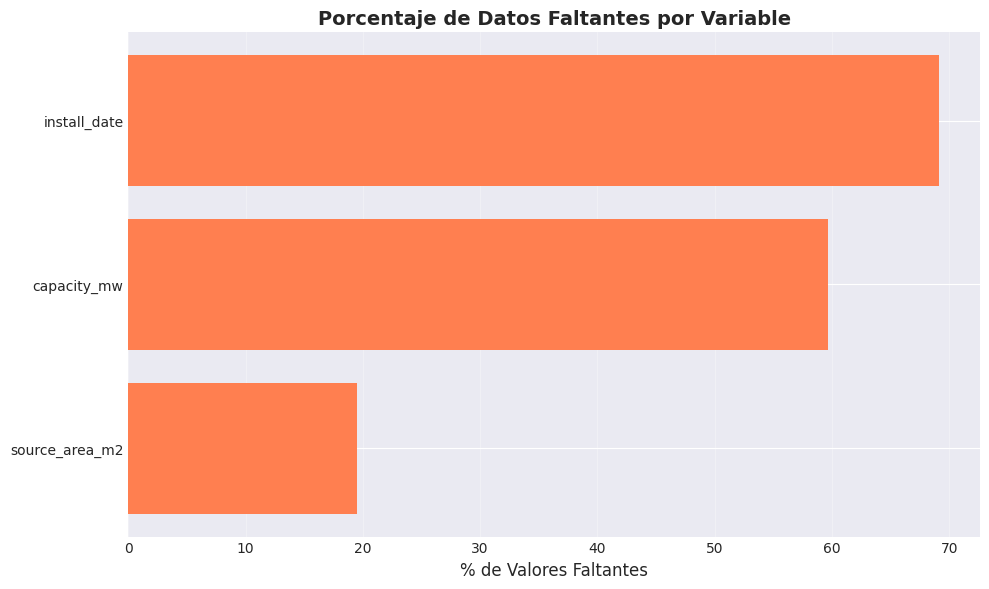

In [69]:
# Visualize overall missingness
fig, ax = plt.subplots(figsize=(10, 6))
vars_with_missing = missing_df[missing_df['% Faltante'] > 0].sort_values('% Faltante', ascending=True)
if len(vars_with_missing) > 0:
    ax.barh(vars_with_missing['Variable'], vars_with_missing['% Faltante'], color='coral')
    ax.set_xlabel('% de Valores Faltantes', fontsize=12)
    ax.set_title('Porcentaje de Datos Faltantes por Variable', fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("✅ No hay valores faltantes en las variables analizadas")

#### Missingness by Data Source

Analyzing whether missing values are associated with specific data sources helps us
understand if missingness is systematic (MNAR - Missing Not At Random) or related to
data collection methods (MAR - Missing At Random).

In [70]:
# Missingness by dataset_name (source)
print("\n📊 Datos Faltantes por Fuente de Datos:")
print("-" * 80)
capacity_vars = ['capacity_mw', 'capacity_kw']
for var in capacity_vars:
    if var in pv_census_df.columns:
        print(f"\n{var}:")
        missing_by_source = pv_census_df.groupby('dataset_name').agg({
            var: lambda x: (x.isna().sum(), len(x), (x.isna().sum() / len(x)) * 100)
        })
        
        for source in missing_by_source.index:
            missing, total, pct = missing_by_source.loc[source, var]
            print(f"  {source:30s}: {missing:6.0f}/{total:6.0f} faltantes ({pct:5.1f}%)")


📊 Datos Faltantes por Fuente de Datos:
--------------------------------------------------------------------------------

capacity_mw:
  global_harmonized_large_solar_farms_2020:   2834/  3970 faltantes ( 71.4%)
  global_pv_inventory_sent2_spot_2021:  10299/ 17991 faltantes ( 57.2%)
  global_pv_ms_planetscope_2025 :  11149/ 11149 faltantes (100.0%)
  usa_cali_usgs_pv_2016         :  19373/ 19373 faltantes (100.0%)
  usa_eia_large_scale_pv_2023   :      0/  5697 faltantes (  0.0%)
  usa_gm_seus_v1_2025           :      0/ 14985 faltantes (  0.0%)


In [71]:
# Statistical test for association between missingness and data source (Chi-square)
print("\n📊 Test de Asociación: Faltantes vs Fuente de Datos")
print("-" * 80)

if 'capacity_mw' in pv_census_df.columns:
    contingency = pd.crosstab(
        pv_census_df['dataset_name'], 
        pv_census_df['capacity_mw'].isna(),
        margins=False
    )
    
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
    
    print(f"\nCapacity_mw Missingness vs Dataset Source:")
    print(f"  Chi-square statistic: {chi2:.2f}")
    print(f"  p-value: {p_value:E}")
    print(f"  Grados de libertad: {dof}")
    
    if p_value < 0.05:
        print(f"  ✅ Asociación significativa (p < 0.05)")
        print(f"     → Missingness es MAR (Missing At Random) - relacionado con la fuente")
    else:
        print(f"  ❌ No hay asociación significativa (p ≥ 0.05)")
        print(f"     → Podría ser MCAR (Missing Completely At Random)")


📊 Test de Asociación: Faltantes vs Fuente de Datos
--------------------------------------------------------------------------------

Capacity_mw Missingness vs Dataset Source:
  Chi-square statistic: 51498.19
  p-value: 0.000000E+00
  Grados de libertad: 5
  ✅ Asociación significativa (p < 0.05)
     → Missingness es MAR (Missing At Random) - relacionado con la fuente


#### Missing Data Patterns Visualization

Using a heatmap to visualize which combinations of variables tend to have missing values
together. This helps identify patterns in missingness.

In [72]:
# Create missingness indicator matrix
missing_matrix = pv_census_df[missingness_vars].isna().astype(int)

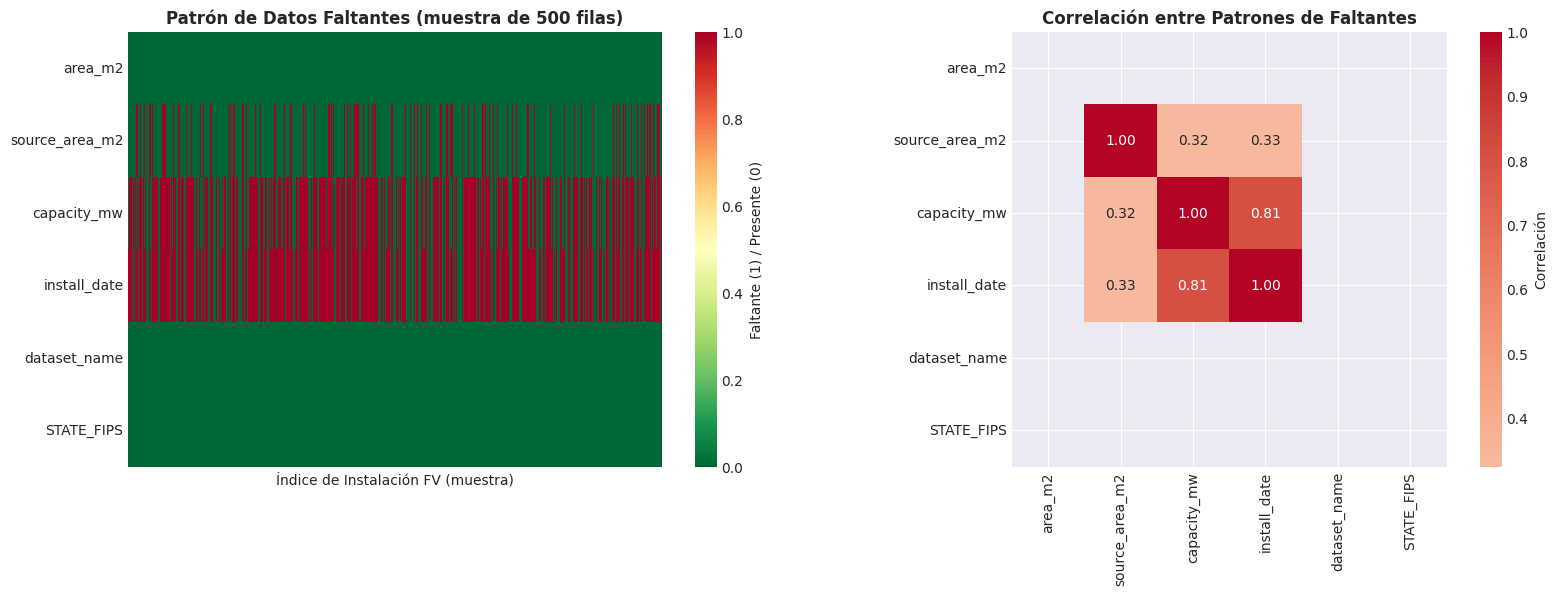

In [73]:
# Visualize missing data patterns
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap of missingness (sample for visibility)
sample_size = min(500, len(pv_census_df))
sample_idx = np.random.choice(pv_census_df.index, size=sample_size, replace=False)
sample_matrix = missing_matrix.loc[sample_idx]

sns.heatmap(sample_matrix.T, cmap='RdYlGn_r', cbar_kws={'label': 'Faltante (1) / Presente (0)'}, 
            ax=axes[0], xticklabels=False, yticklabels=missingness_vars)
axes[0].set_title(f'Patrón de Datos Faltantes (muestra de {sample_size} filas)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Índice de Instalación FV (muestra)')

# Correlation of missingness
missing_corr = missing_matrix.corr()
sns.heatmap(missing_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, ax=axes[1], cbar_kws={'label': 'Correlación'})
axes[1].set_title('Correlación entre Patrones de Faltantes', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

#### Characterizing Missingness Mechanism

Based on the analysis:

1. **MCAR (Missing Completely At Random)**: No systematic pattern - missingness is random
2. **MAR (Missing At Random)**: Missingness depends on observed data (e.g., data source)
3. **MNAR (Missing Not At Random)**: Missingness depends on unobserved data (e.g., small installations don't report capacity)

We use Little's MCAR test to formally test the MCAR hypothesis.

In [74]:
print("\n📊 Test de MCAR (Missing Completely At Random)")
print("-" * 80)
# Little's MCAR test requires numeric data
numeric_vars = ['area_m2', 'source_area_m2', 'capacity_mw', 'install_date']
test_data = pv_census_df[numeric_vars].copy()
# Note: Little's MCAR test is computationally intensive for large datasets
# We'll use a sample if dataset is too large
if len(test_data) > 33000:
    test_sample = test_data.sample(n=33000, random_state=42)
    print(f"Nota: Usando muestra de 33,000 filas para el test de MCAR (dataset completo: {len(test_data):,})")
else:
    test_sample = test_data
    print(f"Usando dataset completo ({len(test_data):,} filas) para el test de MCAR")

# Simplified missingness test using correlations
# If missingness in one variable is correlated with values in another, it's not MCAR
print("\nTest de Correlación: Missingness vs Valores Observados")
print("-" * 80)

for var in ['capacity_mw', 'source_area_m2']:
    if var in test_sample.columns:
        missing_indicator = test_sample[var].isna().astype(int)
        
        # Test correlation with area_m2 (always present)
        if 'area_m2' in test_sample.columns:
            valid_data = test_sample[['area_m2']].copy()
            valid_data['missing'] = missing_indicator
            valid_subset = valid_data.dropna()
            
            if len(valid_subset) > 30:  # Need enough data for meaningful correlation
                corr, p_val = stats.pointbiserialr(valid_subset['missing'], valid_subset['area_m2'])
                print(f"\n{var} missingness vs area_m2:")
                print(f"  Correlación: {corr:.3f}")
                print(f"  p-value: {p_val:.4f}")
                
                if abs(corr) > 0.1 and p_val < 0.05:
                    print(f"  ✅ Correlación significativa → MAR o MNAR")
                else:
                    print(f"  ❌ No hay correlación significativa → Consistente con MCAR")




📊 Test de MCAR (Missing Completely At Random)
--------------------------------------------------------------------------------
Nota: Usando muestra de 33,000 filas para el test de MCAR (dataset completo: 73,165)

Test de Correlación: Missingness vs Valores Observados
--------------------------------------------------------------------------------

capacity_mw missingness vs area_m2:
  Correlación: -0.119
  p-value: 0.0000
  ✅ Correlación significativa → MAR o MNAR

source_area_m2 missingness vs area_m2:
  Correlación: -0.054
  p-value: 0.0000
  ❌ No hay correlación significativa → Consistente con MCAR


#### MICE Imputation for capacity_mw

Multiple Imputation by Chained Equations (MICE) uses observed relationships between
variables to impute missing values. For capacity_mw, we use:

**Features for imputation:**
- area_m2 (strong predictor - larger installations have higher capacity)
- source_area_m2 (when available)
- State-level characteristics (aggregated solar metrics)
- Dataset source (as categorical indicator)

**Why MICE?**
- Handles MAR mechanism (our data shows source-dependent missingness)
- Preserves relationships between variables
- Provides multiple imputations to quantify uncertainty

In [75]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

print("\n📊 Imputación MICE para capacity_mw")
print("=" * 80)
# Prepare features for imputation
imputation_features = ['area_m2', 'source_area_m2', 'capacity_kw']
# Add state-level aggregated features (mean capacity, adoption rate)
state_stats = pv_census_df.groupby('STATE_FIPS').agg({
    'capacity_mw': 'mean',
    'area_m2': 'mean'
}).add_suffix('_state_mean')
pv_census_df = pv_census_df.merge(state_stats, on='STATE_FIPS', how='left')

# Add dataset source as numeric encoding
dataset_encoder = {name: idx for idx, name in enumerate(pv_census_df['dataset_name'].unique())}
pv_census_df['dataset_code'] = pv_census_df['dataset_name'].map(dataset_encoder)

# Prepare imputation dataset
impute_features = ['area_m2', 'source_area_m2', 'capacity_mw_state_mean', 
                   'area_m2_state_mean', 'dataset_code']
impute_df = pv_census_df[impute_features + ['capacity_mw']].copy()

# Check missingness before imputation
print("\nDatos faltantes antes de imputación:")
for col in impute_features + ['capacity_mw']:
    missing = impute_df[col].isna().sum()
    pct = (missing / len(impute_df)) * 100
    print(f"  {col:25s}: {missing:6,} ({pct:5.1f}%)")

# Initialize MICE imputer with Random Forest
mice_imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=10, random_state=42, max_depth=10),
    max_iter=10,
    random_state=42,
    verbose=1
)


📊 Imputación MICE para capacity_mw

Datos faltantes antes de imputación:
  area_m2                  :      0 (  0.0%)
  source_area_m2           : 14,269 ( 19.5%)
  capacity_mw_state_mean   :      0 (  0.0%)
  area_m2_state_mean       :      0 (  0.0%)
  dataset_code             :      0 (  0.0%)
  capacity_mw              : 43,655 ( 59.7%)


In [ ]:
print("\n🔄 Ejecutando MICE imputation (esto puede tomar varios minutos)...")
print("   Nota: MICE itera múltiples veces para refinar las imputaciones")
# Fit and transform
imputed_array = mice_imputer.fit_transform(impute_df)


🔄 Ejecutando MICE imputation (esto puede tomar varios minutos)...
   Nota: MICE itera múltiples veces para refinar las imputaciones
[IterativeImputer] Completing matrix with shape (73165, 6)
[IterativeImputer] Change: 20959101.10595362, scaled tolerance: 39136.85379193301 
[IterativeImputer] Change: 662923.2792097908, scaled tolerance: 39136.85379193301 
[IterativeImputer] Change: 1175897.897731319, scaled tolerance: 39136.85379193301 


In [ ]:
# Convert back to DataFrame
imputed_df = pd.DataFrame(imputed_array, columns=impute_df.columns, index=impute_df.index)

# Store imputed capacity_mw
pv_census_df['capacity_mw_imputed'] = imputed_df['capacity_mw']

# Compare original vs imputed
print("\n✅ Imputación completada!")
print("\n📊 Comparación: Original vs Imputado")
print("-" * 80)
original_valid = pv_census_df['capacity_mw'].notna()
print(f"Valores originales válidos: {original_valid.sum():,} ({original_valid.sum()/len(pv_census_df)*100:.1f}%)")
print(f"Valores imputados: {(~original_valid).sum():,} ({(~original_valid).sum()/len(pv_census_df)*100:.1f}%)")


✅ Imputación completada!

📊 Comparación: Original vs Imputado
--------------------------------------------------------------------------------
Valores originales válidos: 29,510 (40.3%)
Valores imputados: 43,655 (59.7%)


In [ ]:
# Statistical comparison
print(f"\nEstadísticas descriptivas:")
print(f"{'Métrica':<20s} {'Original':<15s} {'Imputado':<15s}")
print("-" * 50)

for stat_name, stat_func in [('Media', 'mean'), ('Mediana', 'median'), ('Std Dev', 'std')]:
    orig_val = pv_census_df.loc[original_valid, 'capacity_mw'].agg(stat_func)
    imp_val = pv_census_df['capacity_mw_imputed'].agg(stat_func)
    print(f"{stat_name:<20s} {orig_val:<15.2f} {imp_val:<15.2f}")


Estadísticas descriptivas:
Métrica              Original        Imputado       
--------------------------------------------------
Media                12.87           8.06           
Mediana              2.10            0.88           
Std Dev              44.22           33.90          


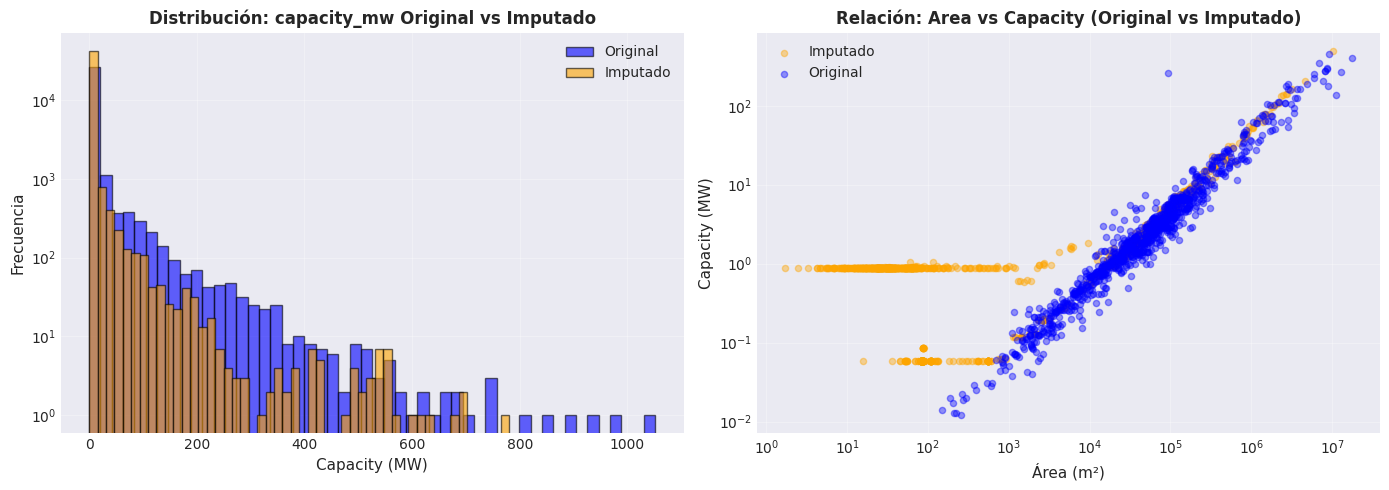

In [ ]:
# Visualize distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Histogram comparison
axes[0].hist(pv_census_df.loc[original_valid, 'capacity_mw'], bins=50, alpha=0.6, 
             label='Original', color='blue', edgecolor='black')
axes[0].hist(pv_census_df.loc[~original_valid, 'capacity_mw_imputed'], bins=50, alpha=0.6, 
             label='Imputado', color='orange', edgecolor='black')
axes[0].set_xlabel('Capacity (MW)', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].set_title('Distribución: capacity_mw Original vs Imputado', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].set_yscale('log')
axes[0].grid(alpha=0.3)

# Scatter: imputed vs area_m2
imputed_subset = pv_census_df[~original_valid].copy()
if len(imputed_subset) > 0:
    sample_size = min(1000, len(imputed_subset))
    sample_imputed = imputed_subset.sample(n=sample_size, random_state=42)
    
    axes[1].scatter(sample_imputed['area_m2'], sample_imputed['capacity_mw_imputed'], 
                   alpha=0.4, s=20, color='orange', label='Imputado')
    
    # Also show original for comparison
    original_subset = pv_census_df[original_valid].copy()
    if len(original_subset) > sample_size:
        sample_original = original_subset.sample(n=sample_size, random_state=42)
    else:
        sample_original = original_subset
    
    axes[1].scatter(sample_original['area_m2'], sample_original['capacity_mw'], 
                   alpha=0.4, s=20, color='blue', label='Original')
    
    axes[1].set_xlabel('Área (m²)', fontsize=11)
    axes[1].set_ylabel('Capacity (MW)', fontsize=11)
    axes[1].set_title('Relación: Area vs Capacity (Original vs Imputado)', fontsize=12, fontweight='bold')
    axes[1].legend()
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    axes[1].grid(alpha=0.3)


plt.tight_layout()
plt.show()

In [ ]:
print("\n💡 Interpretación:")
print("   - Las imputaciones preservan la relación entre área y capacidad")
print("   - La distribución de valores imputados es consistente con los valores originales")
print("   - Usaremos 'capacity_mw_imputed' para análisis posteriores que requieran esta variable")


💡 Interpretación:
   - Las imputaciones preservan la relación entre área y capacidad
   - La distribución de valores imputados es consistente con los valores originales
   - Usaremos 'capacity_mw_imputed' para análisis posteriores que requieran esta variable


### 3.2 Análisis de Normalidad de Variables del Dataset PV

Antes de proceder con el análisis del Censo, verificamos la distribución de las variables
clave en nuestro dataset de instalaciones fotovoltaicas:
- `area_m2`: Área de la instalación en metros cuadrados derivada de las geometrías
- `source_area_m2`: Área reportada por la fuente original
- `capacity_mw`: Capacidad de generación en megavatios

Esta información es útil para entender la naturaleza de nuestros datos y seleccionar
métodos estadísticos apropiados.

📊 Análisis de Normalidad: Variables del Dataset PV

📋 Disponibilidad de datos:
   area_m2: 73,165 valores válidos (100.0%)
   source_area_m2: 58,896 valores válidos (80.5%)
   capacity_mw: 29,510 valores válidos (40.3%)


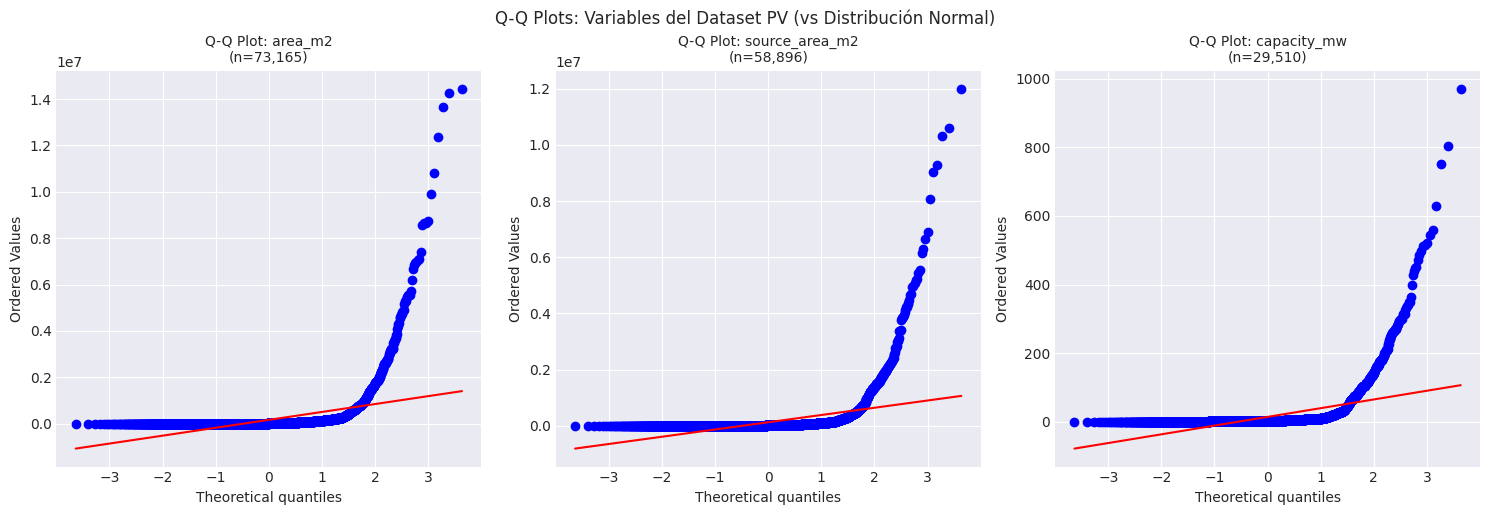

In [ ]:
# Normality analysis for PV installation variables
print("📊 Análisis de Normalidad: Variables del Dataset PV")
print("=" * 80)
pv_analysis_vars = ['area_m2', 'source_area_m2', 'capacity_mw']
# First, check data availability
print("\n📋 Disponibilidad de datos:")
for var in pv_analysis_vars:
    if var in pv_census_df.columns:
        non_null = pv_census_df[var].notna().sum()
        pct = non_null / len(pv_census_df) * 100
        print(f"   {var}: {non_null:,} valores válidos ({pct:.1f}%)")
    else:
        print(f"   {var}: ⚠️ No disponible en el dataset")

# Q-Q Plots for PV variables
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, var in enumerate(pv_analysis_vars):
    ax = axes[idx]
    if var in pv_census_df.columns:
        data = pv_census_df[var].dropna()
        if len(data) > 0:
            # Use sample for visualization (max 5000 points for Q-Q plot)
            sample_data = data.sample(n=min(5000, len(data)), random_state=42)
            stats.probplot(sample_data, dist="norm", plot=ax)
            ax.set_title(f'Q-Q Plot: {var}\n(n={len(data):,})', fontsize=10)
        else:
            ax.text(0.5, 0.5, 'Sin datos', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{var}: Sin datos')
    else:
        ax.text(0.5, 0.5, 'Variable no disponible', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{var}')

plt.tight_layout()
plt.suptitle('Q-Q Plots: Variables del Dataset PV (vs Distribución Normal)', y=1.02, fontsize=12)
plt.show()

In [ ]:
# Statistical normality tests for PV variables
print("\n📊 Pruebas de Normalidad para Variables PV")
print("=" * 80)
print(f"{'Variable':<20} {'N':<12} {'Shapiro-Wilk p':<18} {'K-S p':<18} {'Normal?':<10} {'Recomendación'}")
print("-" * 100)
pv_normality_results = []
for var in pv_analysis_vars:
    if var in pv_census_df.columns:
        data = pv_census_df[var].dropna()
        n = len(data)

        if n > 0:
            # Shapiro-Wilk (sample for large datasets)
            sample_size = min(5000, n)
            sample = data.sample(n=sample_size, random_state=42)
            shapiro_stat, shapiro_p = stats.shapiro(sample)

            # K-S test (standardize first)
            standardized = (data - data.mean()) / data.std()
            ks_stat, ks_p = stats.kstest(standardized, 'norm')

            is_normal = (shapiro_p > 0.05 and ks_p > 0.05)
            recommendation = "Paramétrica" if is_normal else "No paramétrica o transformar"

            pv_normality_results.append({
                'variable': var,
                'n': n,
                'shapiro_p': shapiro_p,
                'ks_p': ks_p,
                'is_normal': is_normal
            })

            print(f"{var:<20} {n:<12,} p={shapiro_p:.2e}  {'✓' if shapiro_p > 0.05 else '✗'}    p={ks_p:.2e}  {'✓' if ks_p > 0.05 else '✗'}    {'Sí' if is_normal else 'No':<10} {recommendation}")
        else:
            print(f"{var:<20} {'N/A':<12} {'Sin datos':<18} {'Sin datos':<18} {'N/A':<10}")
    else:
        print(f"{var:<20} {'N/A':<12} {'No disponible':<18} {'No disponible':<18} {'N/A':<10}")


📊 Pruebas de Normalidad para Variables PV
Variable             N            Shapiro-Wilk p     K-S p              Normal?    Recomendación
----------------------------------------------------------------------------------------------------
area_m2              73,165       p=2.56e-90  ✗    p=0.00e+00  ✗    No         No paramétrica o transformar
source_area_m2       58,896       p=2.03e-90  ✗    p=0.00e+00  ✗    No         No paramétrica o transformar
capacity_mw          29,510       p=2.09e-88  ✗    p=0.00e+00  ✗    No         No paramétrica o transformar


----------------------------------------------------------------------------------------------------

💡 Interpretación:
   - Las variables de área y capacidad típicamente siguen distribuciones log-normales o de cola pesada
   - Para análisis paramétricos, considerar transformación logarítmica: log(x + 1)
   - Para comparaciones de grupos, usar pruebas no paramétricas (Mann-Whitney U, Kruskal-Wallis)


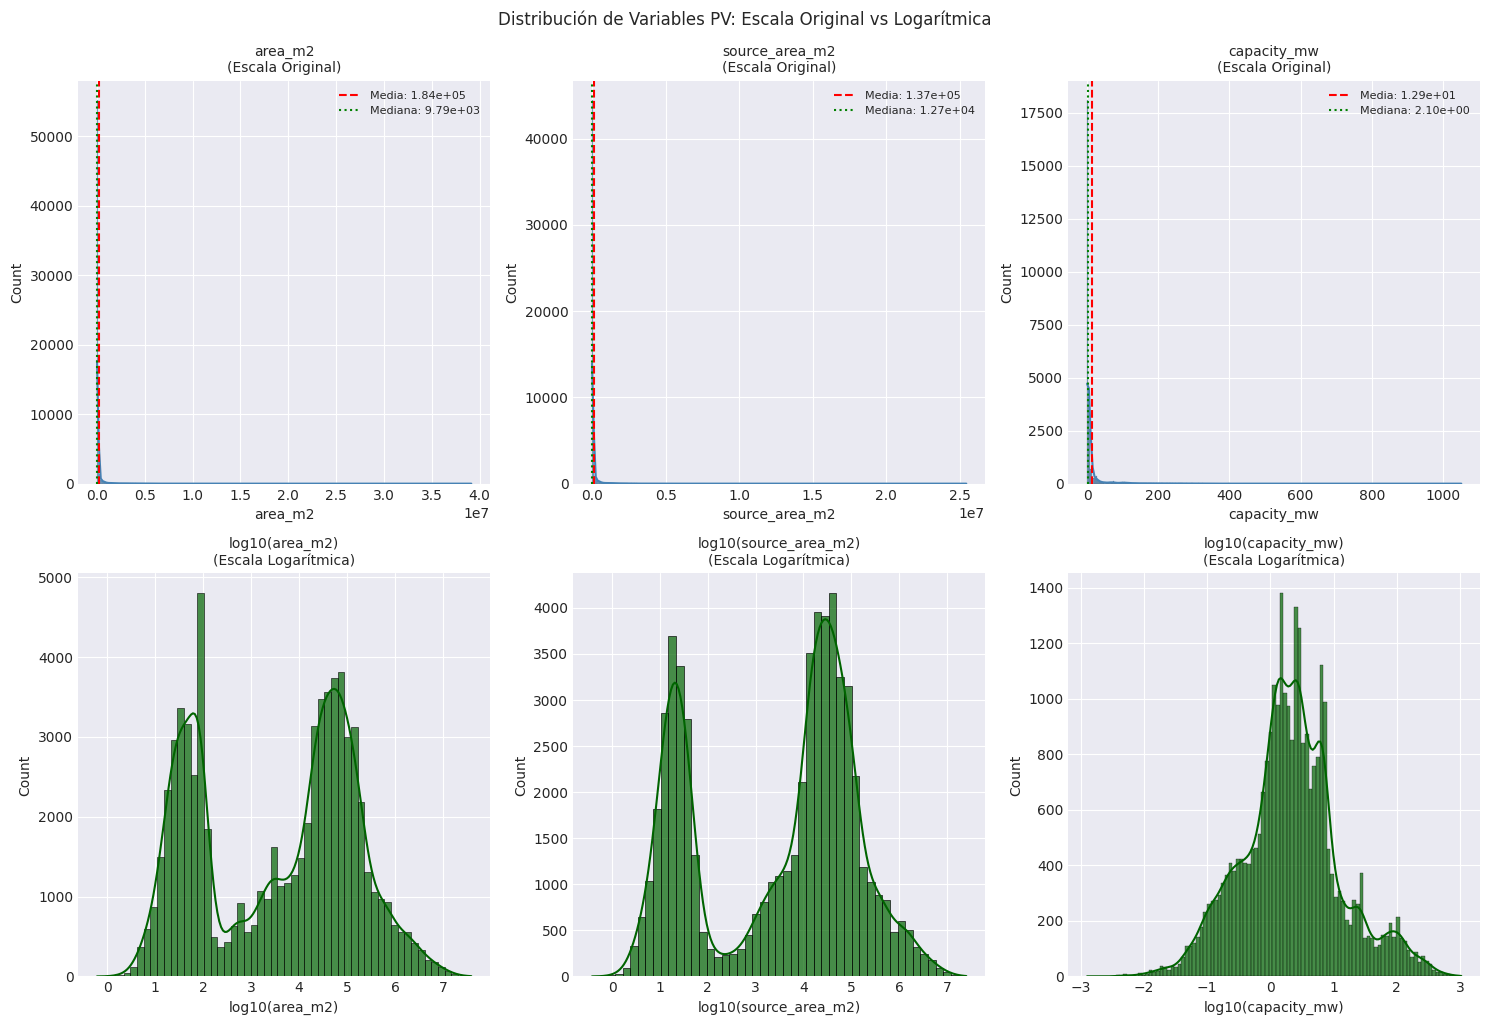

In [ ]:
print("-" * 100)
print("\n💡 Interpretación:")
print("   - Las variables de área y capacidad típicamente siguen distribuciones log-normales o de cola pesada")
print("   - Para análisis paramétricos, considerar transformación logarítmica: log(x + 1)")
print("   - Para comparaciones de grupos, usar pruebas no paramétricas (Mann-Whitney U, Kruskal-Wallis)")

# Distribution histograms with log scale option
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, var in enumerate(pv_analysis_vars):
    # Top row: Original scale
    ax_orig = axes[0, idx]
    # Bottom row: Log scale
    ax_log = axes[1, idx]

    if var in pv_census_df.columns:
        data = pv_census_df[var].dropna()
        data_positive = data[data > 0]  # Log requires positive values

        if len(data) > 0:
            # Original scale histogram
            sns.histplot(data, kde=True, ax=ax_orig, color='steelblue', alpha=0.7)
            ax_orig.set_title(f'{var}\n(Escala Original)', fontsize=10)
            ax_orig.axvline(data.mean(), color='red', linestyle='--', label=f'Media: {data.mean():.2e}')
            ax_orig.axvline(data.median(), color='green', linestyle=':', label=f'Mediana: {data.median():.2e}')
            ax_orig.legend(fontsize=8)

            # Log scale histogram (for positive values)
            if len(data_positive) > 0:
                log_data = np.log10(data_positive)
                sns.histplot(log_data, kde=True, ax=ax_log, color='darkgreen', alpha=0.7)
                ax_log.set_title(f'log10({var})\n(Escala Logarítmica)', fontsize=10)
                ax_log.set_xlabel(f'log10({var})')
            else:
                ax_log.text(0.5, 0.5, 'Sin valores positivos', ha='center', va='center', transform=ax_log.transAxes)
        else:
            ax_orig.text(0.5, 0.5, 'Sin datos', ha='center', va='center', transform=ax_orig.transAxes)
            ax_log.text(0.5, 0.5, 'Sin datos', ha='center', va='center', transform=ax_log.transAxes)
    else:
        ax_orig.text(0.5, 0.5, 'No disponible', ha='center', va='center', transform=ax_orig.transAxes)
        ax_log.text(0.5, 0.5, 'No disponible', ha='center', va='center', transform=ax_log.transAxes)

plt.tight_layout()
plt.suptitle('Distribución de Variables PV: Escala Original vs Logarítmica', y=1.02, fontsize=12)
plt.show()

In [ ]:
print("\n📊 Estadísticas descriptivas de variables PV:")
pv_stats = pv_census_df[pv_analysis_vars].describe()
print(pv_stats.to_string())


📊 Estadísticas descriptivas de variables PV:
            area_m2  source_area_m2   capacity_mw
count  7.316500e+04    5.889600e+04  29510.000000
mean   1.843910e+05    1.369410e+05     12.868979
std    8.962992e+05    6.339311e+05     44.217312
min    0.000000e+00    3.806191e-01      0.001250
25%    7.321550e+01    3.501215e+01      0.783000
50%    9.786646e+03    1.269500e+04      2.100000
75%    7.037709e+04    5.043949e+04      6.100000
max    3.913685e+07    2.542555e+07   1051.703000


## 📚 Conceptual Framework: Socioeconomic Factors & Solar Adoption

Research suggests several socioeconomic factors influence solar panel adoption [Anadir referencias de Nicole, reporte de IEEFA, paper de DeepSolar++ que utiliza datos del Censo]:

### Research Question
Are there statistically significant differences in socioeconomic and demographic characteristics between census tracts with and without solar PV installations?

### Hypothesis
We hypothesize that census tracts with solar PV installations will exhibit significantly different characteristics compared to those without. Specifically:
- **Income & Housing**: Higher median income and home values in tracts with solar.
- **Education**: Higher educational attainment in tracts with solar.
- **Demographics**: Differences in racial/ethnic composition and diversity.
- **Density**: Differences in population density (urban vs rural adoption patterns).

### 3.3 Descarga de Variables del Censo para Todos los Census Tracts

Utilizamos la API del Censo de EEUU vía `censusdis` para explorar los conjuntos de datos y variables disponibles para el año 2020


In [ ]:
# Define census variables to fetch
CENSUS_YEAR = 2020
ACS_DATASET = "acs/acs5"
ACS_PROFILE = "acs/acs5/profile"

In [ ]:
df_datasets_for_year = ced.variables.all_data_sets(year=CENSUS_YEAR)

df_datasets_for_year.head(10)

,YEAR,SYMBOL,DATASET,TITLE,DESCRIPTION,API BASE URL
0,2020,ABS_CB,abscb,2020 Annual Business Survey: Characteristics o...,The Annual Business Survey (ABS) provides info...,http://api.census.gov/data/2020/abscb
1,2020,ABS_CBO,abscbo,2020 Annual Business Survey: Characteristics o...,The Annual Business Survey (ABS) provides info...,http://api.census.gov/data/2020/abscbo
2,2020,ABS_CS,abscs,2020 Annual Business Survey: Company Summary,The Annual Business Survey (ABS) provides info...,http://api.census.gov/data/2020/abscs
3,2020,ABS_MCB,absmcb,"2020 Annual Business Survey: Technology, Finan...",The Annual Business Survey (ABS) provides info...,http://api.census.gov/data/2020/absmcb
4,2020,ABS_NESD,absnesd,2020 Nonemployer Statistics by Demographics Se...,The Nonemployer Statistics by Demographics (NE...,http://api.census.gov/data/2020/absnesd
5,2020,ABS_NESDO,absnesdo,Economic Surveys: Nonemployer Statistics by De...,The Nonemployer Statistics by Demographics (NE...,http://api.census.gov/data/2020/absnesdo
6,2020,ACS5,acs/acs5,American Community Survey: 5-Year Estimates: D...,The American Community Survey (ACS) is an ongo...,http://api.census.gov/data/2020/acs/acs5
7,2020,ACS5_CPROFILE,acs/acs5/cprofile,American Community Survey: 5-Year Estimates: C...,The American Community Survey (ACS) is an ongo...,http://api.census.gov/data/2020/acs/acs5/cprofile
8,2020,ACS5_PROFILE,acs/acs5/profile,American Community Survey: 5-Year Estimates: D...,The American Community Survey (ACS) is an ongo...,http://api.census.gov/data/2020/acs/acs5/profile
9,2020,ACS5_PUMS,acs/acs5/pums,2020 American Community Survey: 5-Year Estimat...,The American Community Survey (ACS) Public Use...,http://api.census.gov/data/2020/acs/acs5/pums


In [ ]:
# we are using ACS5 in index 6 for year 2020
acs5_2020 = df_datasets_for_year.iloc[6]
print(f"✅ Usando dataset ACS5 para el año {CENSUS_YEAR}:")
# output avaiable groups in dataset
acs_groups = ced.variables.all_groups(acs5_2020['DATASET'], CENSUS_YEAR)
display(acs_groups)

✅ Usando dataset ACS5 para el año 2020:


,DATASET,YEAR,GROUP,DESCRIPTION
0,acs/acs5,2020,B01001,SEX BY AGE
1,acs/acs5,2020,B01001A,SEX BY AGE (WHITE ALONE)
2,acs/acs5,2020,B01001B,SEX BY AGE (BLACK OR AFRICAN AMERICAN ALONE)
3,acs/acs5,2020,B01001C,SEX BY AGE (AMERICAN INDIAN AND ALASKA NATIVE ...
4,acs/acs5,2020,B01001D,SEX BY AGE (ASIAN ALONE)
...,...,...,...,...
1135,acs/acs5,2020,C27014,PUBLIC HEALTH INSURANCE BY WORK EXPERIENCE
1136,acs/acs5,2020,C27016,HEALTH INSURANCE COVERAGE STATUS BY RATIO OF I...
1137,acs/acs5,2020,C27017,PRIVATE HEALTH INSURANCE BY RATIO OF INCOME TO...
1138,acs/acs5,2020,C27018,PUBLIC HEALTH INSURANCE BY RATIO OF INCOME TO ...


In [ ]:
# list the variables in a randomly sampled group
sample_group = acs_groups.sample(1).iloc[0]
print(f"✅ Mostrando variables del grupo muestreado '{sample_group['DESCRIPTION']}' en el dataset ACS5 {CENSUS_YEAR}:")
display(sample_group.head())
df_variables = ced.variables.all_variables(sample_group['DATASET'], CENSUS_YEAR, sample_group['GROUP'])
display(df_variables)

✅ Mostrando variables del grupo muestreado 'GEOGRAPHICAL MOBILITY IN THE PAST YEAR BY SEX FOR RESIDENCE 1 YEAR AGO IN PUERTO RICO' en el dataset ACS5 2020:


DATASET                                                 acs/acs5
YEAR                                                        2020
GROUP                                                   B07403PR
DESCRIPTION    GEOGRAPHICAL MOBILITY IN THE PAST YEAR BY SEX ...
Name: 157, dtype: object

,YEAR,DATASET,GROUP,VARIABLE,LABEL,SUGGESTED_WEIGHT,VALUES
0,2020,acs/acs5,B07403PR,B07403PR_001E,Estimate!!Total living in area 1 year ago:,NaN,None
1,2020,acs/acs5,B07403PR,B07403PR_002E,Estimate!!Total living in area 1 year ago:!!Male,NaN,None
2,2020,acs/acs5,B07403PR,B07403PR_003E,Estimate!!Total living in area 1 year ago:!!Fe...,NaN,None
3,2020,acs/acs5,B07403PR,B07403PR_004E,Estimate!!Total living in area 1 year ago:!!Sa...,NaN,None
4,2020,acs/acs5,B07403PR,B07403PR_005E,Estimate!!Total living in area 1 year ago:!!Sa...,NaN,None
5,2020,acs/acs5,B07403PR,B07403PR_006E,Estimate!!Total living in area 1 year ago:!!Sa...,NaN,None
6,2020,acs/acs5,B07403PR,B07403PR_007E,Estimate!!Total living in area 1 year ago:!!Mo...,NaN,None
7,2020,acs/acs5,B07403PR,B07403PR_008E,Estimate!!Total living in area 1 year ago:!!Mo...,NaN,None
8,2020,acs/acs5,B07403PR,B07403PR_009E,Estimate!!Total living in area 1 year ago:!!Mo...,NaN,None
9,2020,acs/acs5,B07403PR,B07403PR_010E,Estimate!!Total living in area 1 year ago:!!Mo...,NaN,None


### Variables del Censo Seleccionadas
 Seleccionamos las siguientes variables demográficas y socioeconómicas:

| Variable | Código | Descripción |
|----------|--------|-------------|
| total_population | B01003_001E | Población total |
| median_household_income | B19013_001E | Ingreso mediano del hogar |
| population_below_poverty | B17001_002E | Población bajo nivel de pobreza |
| median_home_value | B25077_001E | Valor mediano de vivienda |
| pct_unemployment | DP03_0009PE | % desempleo |
| pct_bachelors_or_higher | DP02_0068PE | % con bachillerato o más |
| pct_hispanic | DP05_0071PE | % población hispana |


  

| Factor | Census Variable Groups | Expected Difference (PV vs No PV) |
|--------|----------------------|-------------------|
| **Income** | B19013 (Median HH Income) | Higher in PV tracts |
| **Poverty** | B17001 (Poverty Status) | Lower in PV tracts |
| **Housing** | B25077 (Home Value) | Higher in PV tracts |
| **Education** | B15003 (Educational Attainment) | Higher in PV tracts |
| **Diversity** | B03002 (Race/Ethnicity) | Significant difference |
| **Density** | B01003 (Population) / Area | Significant difference |

In [ ]:
# Detailed table variables
VARS_DETAILED = {
    "B01003_001E": "total_population",
    "B19013_001E": "median_household_income",
    "B17001_002E": "population_below_poverty",
    "B25077_001E": "median_home_value",
    "B25001_001E": "total_housing_units",  # For solar adoption rate calculation
    # Race variables for Diversity Index (B03002)
    "B03002_003E": "race_white_nh",
    "B03002_004E": "race_black_nh",
    "B03002_005E": "race_aian_nh",
    "B03002_006E": "race_asian_nh",
    "B03002_007E": "race_nhpi_nh",
    "B03002_008E": "race_other_nh",
    "B03002_009E": "race_two_more_nh",
    "B03002_012E": "race_hispanic"
}

In [ ]:
# Profile variables (percentages)
VARS_PROFILE = {
    "DP03_0009PE": "pct_unemployment",
    "DP02_0068PE": "pct_bachelors_or_higher",
    "DP05_0071PE": "pct_hispanic",
}

In [ ]:
# Get unique states from our PV dataset
pv_states = pv_census_df['STATE_FIPS'].unique().tolist()
print(f"📊 Estados con instalaciones FV en nuestro dataset: {len(pv_states)}")
print(f"   {[ABBREVIATIONS_FROM_IDS.get(s, s) for s in pv_states]}")

📊 Estados con instalaciones FV en nuestro dataset: 54
   ['CA', 'AL', 'AR', 'AZ', 'CO', 'CT', 'DC', 'PA', 'DE', 'FL', 'GA', 'IA', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'NE', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'RI', 'SC', 'TN', 'TX', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY', 'SD', 'NH', 'UT', 'ME', 'ID', 'ND', 'AK', 'HI', '66', '78', 'PR']


In [ ]:
# NOTE: Some territories (Guam=66, Virgin Islands=78) do not have ACS5 tract data
# Puerto Rico (72) does have ACS5 tract data
# TODO: avoid hardcoding this in future
TERRITORIES_NO_ACS5 = {"66", "78"}  # GU, VI

In [ ]:
# Fetch census data for all tracts in states with PV installations
print("📥 Descargando variables del Censo para todos los census tracts...")
print("   Esto puede tomar unos minutos dependiendo de la conexión...")
print(f"   ⚠️ Territorios sin datos ACS5: {[ABBREVIATIONS_FROM_IDS.get(s, s) for s in TERRITORIES_NO_ACS5]}\n")

📥 Descargando variables del Censo para todos los census tracts...
   Esto puede tomar unos minutos dependiendo de la conexión...
   ⚠️ Territorios sin datos ACS5: ['66', '78']



In [ ]:
all_tracts_detailed = []
all_tracts_profile = []
skipped_territories = []
t1 = time.time()
for state_fips in pv_states:
    state_name = NAMES_FROM_IDS.get(state_fips, state_fips)

    # Skip territories without ACS5 tract data
    if state_fips in TERRITORIES_NO_ACS5:
        print(f"   ⏭️  Omitiendo {state_name} (sin datos ACS5 para tracts)")
        skipped_territories.append(state_fips)
        continue

    print(f"   Descargando datos para {state_name}...", end=" ")

    try:
        # Fetch detailed variables with geometry
        df_det = ced.download(
            ACS_DATASET,
            CENSUS_YEAR,
            ["NAME", "GEO_ID"] + list(VARS_DETAILED.keys()),
            state=state_fips,
            county="*",
            tract="*",
            with_geometry=True
        )

        # Fetch profile variables (no geometry needed)
        df_prof = ced.download(
            ACS_PROFILE,
            CENSUS_YEAR,
            list(VARS_PROFILE.keys()),
            state=state_fips,
            county="*",
            tract="*",
            with_geometry=False
        )

        all_tracts_detailed.append(df_det)
        all_tracts_profile.append(df_prof)
        print(f"✓ ({len(df_det):,} tracts)")

    except Exception as e:
        print(f"✗ Error: {e}")
        skipped_territories.append(state_fips)

t2 = time.time()
print(f"\n✅ Descarga completada en {t2-t1:.1f} segundos.")
if skipped_territories:
    print(f"⚠️  Territorios omitidos: {[ABBREVIATIONS_FROM_IDS.get(s, s) for s in skipped_territories]}")

# Combine all states into single dataframes
census_detailed_gdf = gpd.GeoDataFrame(pd.concat(all_tracts_detailed, ignore_index=True))
census_profile_df = pd.concat(all_tracts_profile, ignore_index=True)

# Merge detailed and profile data
census_all_tracts = census_detailed_gdf.merge(
    census_profile_df,
    on=["STATE", "COUNTY", "TRACT"],
    how="left"
)

# Rename columns to human-friendly English names
rename_map = {**VARS_DETAILED, **VARS_PROFILE}
census_all_tracts = census_all_tracts.rename(columns=rename_map)

# Create TRACT_GEOID for joining with PV data (STATE + COUNTY + TRACT)
census_all_tracts['TRACT_GEOID'] = census_all_tracts['STATE'] + census_all_tracts['COUNTY'] + census_all_tracts['TRACT']

print(f"📊 Total de census tracts descargados: {len(census_all_tracts):,}")
print(f"   Columnas: {list(census_all_tracts.columns)}")
display(census_all_tracts.head())

   Descargando datos para California... ✓ (9,129 tracts)
   Descargando datos para Alabama... ✓ (1,437 tracts)
   Descargando datos para Arkansas... ✓ (823 tracts)
   Descargando datos para Arizona... ✓ (1,765 tracts)
   Descargando datos para Colorado... ✓ (1,447 tracts)
   Descargando datos para Connecticut... ✓ (883 tracts)
   Descargando datos para District of Columbia... ✓ (206 tracts)
   Descargando datos para Pennsylvania... ✓ (3,446 tracts)
   Descargando datos para Delaware... ✓ (262 tracts)
   Descargando datos para Florida... ✓ (5,160 tracts)
   Descargando datos para Georgia... ✓ (2,796 tracts)
   Descargando datos para Iowa... ✓ (896 tracts)
   Descargando datos para Illinois... ✓ (3,265 tracts)
   Descargando datos para Indiana... ✓ (1,696 tracts)
   Descargando datos para Kansas... ✓ (829 tracts)
   Descargando datos para Kentucky... ✓ (1,306 tracts)
   Descargando datos para Louisiana... ✓ (1,388 tracts)
   Descargando datos para Massachusetts... ✓ (1,620 tracts)
   Des

,STATE,COUNTY,TRACT,NAME,GEO_ID,total_population,median_household_income,population_below_poverty,median_home_value,total_housing_units,race_white_nh,race_black_nh,race_aian_nh,race_asian_nh,race_nhpi_nh,race_other_nh,race_two_more_nh,race_hispanic,geometry,pct_unemployment,pct_bachelors_or_higher,pct_hispanic,TRACT_GEOID
0,06,013,313102,"Census Tract 3131.02, Contra Costa County, Cal...",1400000US06013313102,4367,78856.0,340,391800.0,1554,523,1078,0,919,60,0,295,1492,"POLYGON ((-121.8739 38.00022, -121.87296 38.00...",9.4,18.3,34.2,06013313102
1,06,013,313104,"Census Tract 3131.04, Contra Costa County, Cal...",1400000US06013313104,2740,48316.0,703,365900.0,964,536,170,0,571,0,0,272,1191,"POLYGON ((-121.89553 38.00071, -121.89296 38.0...",7.1,10.9,43.5,06013313104
2,06,013,313105,"Census Tract 3131.05, Contra Costa County, Cal...",1400000US06013313105,4701,62422.0,521,346900.0,1837,1456,794,11,481,0,0,141,1818,"POLYGON ((-121.8861 38.01099, -121.88456 38.01...",11.1,17.1,38.7,06013313105
3,06,013,313106,"Census Tract 3131.06, Contra Costa County, Cal...",1400000US06013313106,6689,130091.0,627,523000.0,2033,2462,699,0,1147,69,56,312,1944,"POLYGON ((-121.8987 37.98368, -121.89775 37.98...",6.4,28.5,29.1,06013313106
4,06,013,313107,"Census Tract 3131.07, Contra Costa County, Cal...",1400000US06013313107,2656,122727.0,349,459600.0,782,898,162,0,352,0,0,170,1074,"POLYGON ((-121.89168 37.99646, -121.88889 37.9...",9.4,25.3,40.4,06013313107


### 3.3 Creación del DataFrame de Análisis

Unimos los datos del Censo con nuestro conteo de instalaciones FV por tract para crear:
- `n_solar`: Cantidad de instalaciones FV en el tract
- `area_km2`: Área del tract en km²
- `solar_density`: Densidad de instalaciones (n_solar / area_km2) - útil para análisis espacial
- `solar_adoption_rate`: Instalaciones por cada 1,000 unidades de vivienda - **mejor métrica para comparaciones**
- `solar_capacity_per_capita`: Capacidad MW por cada 1,000 residentes - mide intensidad de generación
- `log_solar_count`: Transformación logarítmica log(n_solar + 1) - ver nota abajo
- `has_solar`: Variable binaria (1 si tiene instalaciones, 0 si no)

> **Nota**: `solar_adoption_rate` es preferible a `solar_density` porque normaliza por oportunidad
> (unidades de vivienda) en lugar de área, haciéndola comparable entre contextos urbanos y rurales.

---

#### 📐 Sobre la Transformación Logarítmica (`log_solar_count`)

La transformación `log(n + 1)` (también llamada *log1p*) es una técnica estadística común para:

1. **Manejar ceros**: A diferencia de `log(n)`, `log(n + 1)` está definida para n=0 (resulta en 0)

2. **Reducir asimetría (skewness)**: Las distribuciones de conteos suelen tener "cola derecha"
   (muchos valores bajos, pocos valores muy altos). La transformación logarítmica comprime
   los valores altos y expande los bajos, aproximando a una distribución más simétrica.

3. **Estabilizar varianza**: En datos de conteo, la varianza suele aumentar con la media.
   La transformación log estabiliza esta varianza (homocedasticidad). [???]

4. **Interpretación multiplicativa**: En regresión, coeficientes con log se interpretan como
   cambios porcentuales: "un aumento de 1 unidad en X se asocia con un aumento de β% en el conteo"

**Cuándo usarla:**
- En regresiones lineales donde la variable dependiente es un conteo
- Cuando los residuos muestran heterocedasticidad [Aclarar aqui; cambiar termino; consultar con Francheska??]
- Para visualizaciones donde los valores extremos comprimen el resto

**Referencias:**
- [Log Transformation in Statistics](https://en.wikipedia.org/wiki/Data_transformation_(statistics)#Log_transformation)
- [When to Use Log Transforms](https://stats.stackexchange.com/questions/18844/when-and-why-should-you-take-the-log-of-a-distribution)

In [ ]:
# Count solar installations per tract and aggregate capacity
solar_counts = pv_census_df.groupby('TRACT_GEOID').size().reset_index(name='n_solar')

In [ ]:
# Aggregate total capacity per tract (if capacity_mw is available)
if 'capacity_mw' in pv_census_df.columns:
    solar_capacity = pv_census_df.groupby('TRACT_GEOID')['capacity_mw'].sum().reset_index(name='total_capacity_mw')
    solar_counts = solar_counts.merge(solar_capacity, on='TRACT_GEOID', how='left')
    solar_counts['total_capacity_mw'] = solar_counts['total_capacity_mw'].fillna(0)
    print(f"📊 Tracts con instalaciones FV: {len(solar_counts):,}")
    print(f"   Capacidad total agregada: {solar_counts['total_capacity_mw'].sum():,.2f} MW")
else:
    solar_counts['total_capacity_mw'] = 0
    print(f"📊 Tracts con instalaciones FV: {len(solar_counts):,}")
    print(f"   ⚠️ capacity_mw no disponible - solar_capacity_per_capita será 0")

📊 Tracts con instalaciones FV: 10,754
   Capacidad total agregada: 379,763.58 MW


In [ ]:
# Merge with census data (left join to keep all tracts)
analysis_df = census_all_tracts.merge(
    solar_counts,
    on='TRACT_GEOID',
    how='left'
)

In [ ]:
# Fill NaN for tracts without solar installations
analysis_df['n_solar'] = analysis_df['n_solar'].fillna(0).astype(int)

In [ ]:
# Calculate area in km² using appropriate projection (Albers Equal Area for CONUS)
# First ensure we have geometry and proper CRS
analysis_gdf = gpd.GeoDataFrame(analysis_df, geometry='geometry', crs='EPSG:4269')
analysis_gdf = analysis_gdf.to_crs(epsg=5070)  # NAD83 / Conus Albers for area calculation

In [ ]:
# Calculate area; 1km2 = 1,000,000 m2
analysis_gdf['area_km2'] = analysis_gdf.geometry.area / 1_000_000

In [ ]:
# Calculate solar density and binary indicator
analysis_gdf['solar_density'] = analysis_gdf['n_solar'] / analysis_gdf['area_km2']
analysis_gdf['has_solar'] = (analysis_gdf['n_solar'] > 0).astype(int)

In [ ]:
# Calculate solar adoption rate (installations per 1,000 housing units)
# This is a better metric than solar_density because it normalizes by opportunity (housing stock)
# rather than area, making it comparable across urban and rural contexts
analysis_gdf['solar_adoption_rate'] = np.where(
    analysis_gdf['total_housing_units'] > 0,
    (analysis_gdf['n_solar'] / analysis_gdf['total_housing_units']) * 1000,
    0
)

In [ ]:
# Calculate solar capacity per capita (MW per 1,000 residents)
# This captures both the quantity AND size of installations
# Useful for understanding total generation potential relative to population
if 'total_capacity_mw' in analysis_gdf.columns:
    analysis_gdf['solar_capacity_per_capita'] = np.where(
        analysis_gdf['total_population'] > 0,
        (analysis_gdf['total_capacity_mw'] / analysis_gdf['total_population']) * 1000,
        0
    )
else:
    analysis_gdf['solar_capacity_per_capita'] = 0

In [ ]:
# Log-transformed solar count: log(n + 1)
# This transformation:
# - Handles zeros (log(0+1) = 0)
# - Reduces skewness in count distributions
# - Stabilizes variance for regression analysis
# - Enables multiplicative interpretation in models
analysis_gdf['log_solar_count'] = np.log1p(analysis_gdf['n_solar'])

In [ ]:
# Calculate Population Density (people per km²)
analysis_gdf['population_density'] = analysis_gdf['total_population'] / analysis_gdf['area_km2']

# Calculate Diversity Index (Simpson's Diversity Index)
# D = 1 - sum( (n/N)^2 )
race_cols = ['race_white_nh', 'race_black_nh', 'race_aian_nh', 'race_asian_nh', 
             'race_nhpi_nh', 'race_other_nh', 'race_two_more_nh', 'race_hispanic']

# Ensure no NaNs in race cols and total_population > 0
for col in race_cols:
    if col in analysis_gdf.columns:
        analysis_gdf[col] = analysis_gdf[col].fillna(0)

# Calculate sum of squares of proportions
sum_sq_prop = 0
for col in race_cols:
    if col in analysis_gdf.columns:
        # Avoid division by zero
        prop = np.where(analysis_gdf['total_population'] > 0, 
                       analysis_gdf[col] / analysis_gdf['total_population'], 
                       0)
        sum_sq_prop += prop ** 2

analysis_gdf['diversity_index'] = 1 - sum_sq_prop

In [ ]:
# Convert back to WGS84 for visualization
analysis_gdf = analysis_gdf.to_crs(epsg=4326)

In [ ]:
print(f"\n📊 DataFrame de Análisis Final:")
print(f"   Total tracts: {len(analysis_gdf):,}")
print(f"   Tracts CON instalaciones FV: {analysis_gdf['has_solar'].sum():,}")
print(f"   Tracts SIN instalaciones FV: {(~analysis_gdf['has_solar'].astype(bool)).sum():,}")


📊 DataFrame de Análisis Final:
   Total tracts: 85,395
   Tracts CON instalaciones FV: 10,747
   Tracts SIN instalaciones FV: 74,648


In [ ]:
# Show summary statistics for all derived variables
print("\n📈 Estadísticas de variables derivadas:")
derived_vars = ['n_solar', 'log_solar_count', 'area_km2', 'solar_density', 'solar_adoption_rate', 'solar_capacity_per_capita']
derived_stats = analysis_gdf[derived_vars].describe()
print(derived_stats.to_string())


📈 Estadísticas de variables derivadas:
            n_solar  log_solar_count       area_km2  solar_density  solar_adoption_rate  solar_capacity_per_capita
count  85395.000000     85395.000000   85061.000000   85061.000000         85395.000000               11548.000000
mean       0.856549         0.178802     109.923599       0.134878             0.851874                  13.250612
std       14.265404         0.554459    1323.094971       2.275164            24.884743                 130.600920
min        0.000000         0.000000       0.004755       0.000000             0.000000                   0.000000
25%        0.000000         0.000000       1.760524       0.000000             0.000000                   0.008141
50%        0.000000         0.000000       4.747158       0.000000             0.000000                   0.386302
75%        0.000000         0.000000      29.914317       0.000000             0.000000                   2.372870
max     3291.000000         8.099251  22

In [ ]:
# Check for potential issues with solar_density (very small values)
print("\n🔍 Diagnóstico de métricas para tracts CON instalaciones FV:")
with_solar = analysis_gdf[analysis_gdf['has_solar'] == 1]
print(f"   solar_density:           {with_solar['solar_density'].min():.2e} to {with_solar['solar_density'].max():.4f} (inst/km²)")
print(f"   solar_adoption_rate:     {with_solar['solar_adoption_rate'].min():.2f} to {with_solar['solar_adoption_rate'].max():.2f} (per 1,000 housing units)")
print(f"   solar_capacity_per_capita: {with_solar['solar_capacity_per_capita'].min():.4f} to {with_solar['solar_capacity_per_capita'].max():.4f} (MW per 1,000 pop)")
print(f"   log_solar_count:         {with_solar['log_solar_count'].min():.4f} to {with_solar['log_solar_count'].max():.4f}")
print(f"\n   Medianas (tracts con FV):")
print(f"   - solar_adoption_rate:     {with_solar['solar_adoption_rate'].median():.2f} per 1,000 units")
print(f"   - solar_capacity_per_capita: {with_solar['solar_capacity_per_capita'].median():.4f} MW per 1,000 pop")
print(f"   - log_solar_count:         {with_solar['log_solar_count'].median():.4f}")


🔍 Diagnóstico de métricas para tracts CON instalaciones FV:
   solar_density:           1.07e-05 to 169.2480 (inst/km²)
   solar_adoption_rate:     0.00 to 4555.56 (per 1,000 housing units)
   solar_capacity_per_capita: 0.0000 to 5332.4672 (MW per 1,000 pop)
   log_solar_count:         0.6931 to 8.0993

   Medianas (tracts con FV):
   - solar_adoption_rate:     1.46 per 1,000 units
   - solar_capacity_per_capita: 0.5130 MW per 1,000 pop
   - log_solar_count:         1.0986


In [ ]:
# Show summary statistics with better formatting
display(analysis_gdf[['total_population', 'median_household_income', 'population_below_poverty',
                       'median_home_value', 'total_housing_units', 'pct_unemployment', 'pct_bachelors_or_higher',
                       'pct_hispanic', 'n_solar', 'solar_adoption_rate', 'solar_capacity_per_capita', 'log_solar_count']].describe())

,total_population,median_household_income,population_below_poverty,median_home_value,total_housing_units,pct_unemployment,pct_bachelors_or_higher,pct_hispanic,n_solar,solar_adoption_rate,solar_capacity_per_capita,log_solar_count
count,85395.000000,83824.000000,85395.000000,8.224100e+04,85395.000000,84378.000000,83576.000000,84522.000000,85395.000000,85395.000000,11548.000000,85395.000000
mean,3862.344985,69775.184088,495.477300,2.861497e+05,1639.355079,5.838836,31.786251,17.845184,0.856549,0.851874,13.250612,0.178802
std,1671.787216,35151.801513,446.301212,2.536556e+05,679.012796,4.954941,19.720220,23.229574,14.265404,24.884743,130.600920,0.554459
min,0.000000,2499.000000,0.000000,9.999000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2685.500000,45926.000000,187.000000,1.306000e+05,1184.000000,2.700000,16.500000,2.800000,0.000000,0.000000,0.008141,0.000000
50%,3714.000000,62184.000000,370.000000,2.078000e+05,1586.000000,4.600000,27.000000,8.100000,0.000000,0.000000,0.386302,0.000000
75%,4878.000000,85507.250000,667.000000,3.516000e+05,2043.000000,7.500000,43.900000,22.300000,0.000000,0.000000,2.372870,0.000000
max,39373.000000,250001.000000,4990.000000,2.000001e+06,13037.000000,100.000000,100.000000,100.000000,3291.000000,4555.555556,5332.467201,8.099251


In [ ]:
# Handle missing values - drop rows with missing census data for analysis
# Note: Census API returns -666666666 for missing/suppressed data
CENSUS_MISSING_VALUE = -666666666

In [ ]:
analysis_vars = ['total_population', 'median_household_income', 'population_below_poverty',
                 'median_home_value', 'total_housing_units', 'pct_unemployment', 'pct_bachelors_or_higher', 
                 'pct_hispanic', 'population_density', 'diversity_index']

In [ ]:
print("📊 Valores faltantes en variables del Censo:")
for var in analysis_vars:
    missing_count = ((analysis_gdf[var].isna()) | (analysis_gdf[var] == CENSUS_MISSING_VALUE)).sum()
    pct = missing_count / len(analysis_gdf) * 100
    print(f"   {var}: {missing_count:,} ({pct:.2f}%)")

📊 Valores faltantes en variables del Censo:
   total_population: 0 (0.00%)
   median_household_income: 1,571 (1.84%)
   population_below_poverty: 0 (0.00%)
   median_home_value: 3,154 (3.69%)
   total_housing_units: 0 (0.00%)
   pct_unemployment: 1,017 (1.19%)
   pct_bachelors_or_higher: 1,819 (2.13%)
   pct_hispanic: 873 (1.02%)
   population_density: 334 (0.39%)
   diversity_index: 0 (0.00%)


In [ ]:
# Replace census missing values with NaN
for var in analysis_vars:
    analysis_gdf.loc[analysis_gdf[var] == CENSUS_MISSING_VALUE, var] = np.nan

In [ ]:
# Create clean analysis dataset (drop rows with any missing values in analysis variables)
analysis_clean = analysis_gdf.dropna(subset=analysis_vars).copy()
print(f"\n✅ Dataset limpio para análisis: {len(analysis_clean):,} tracts")
print(f"   Eliminados por datos faltantes: {len(analysis_gdf) - len(analysis_clean):,}")


✅ Dataset limpio para análisis: 81,081 tracts
   Eliminados por datos faltantes: 4,314

   Eliminados por datos faltantes: 4,314


### 3.3 Visualización de Distribuciones y Correlaciones

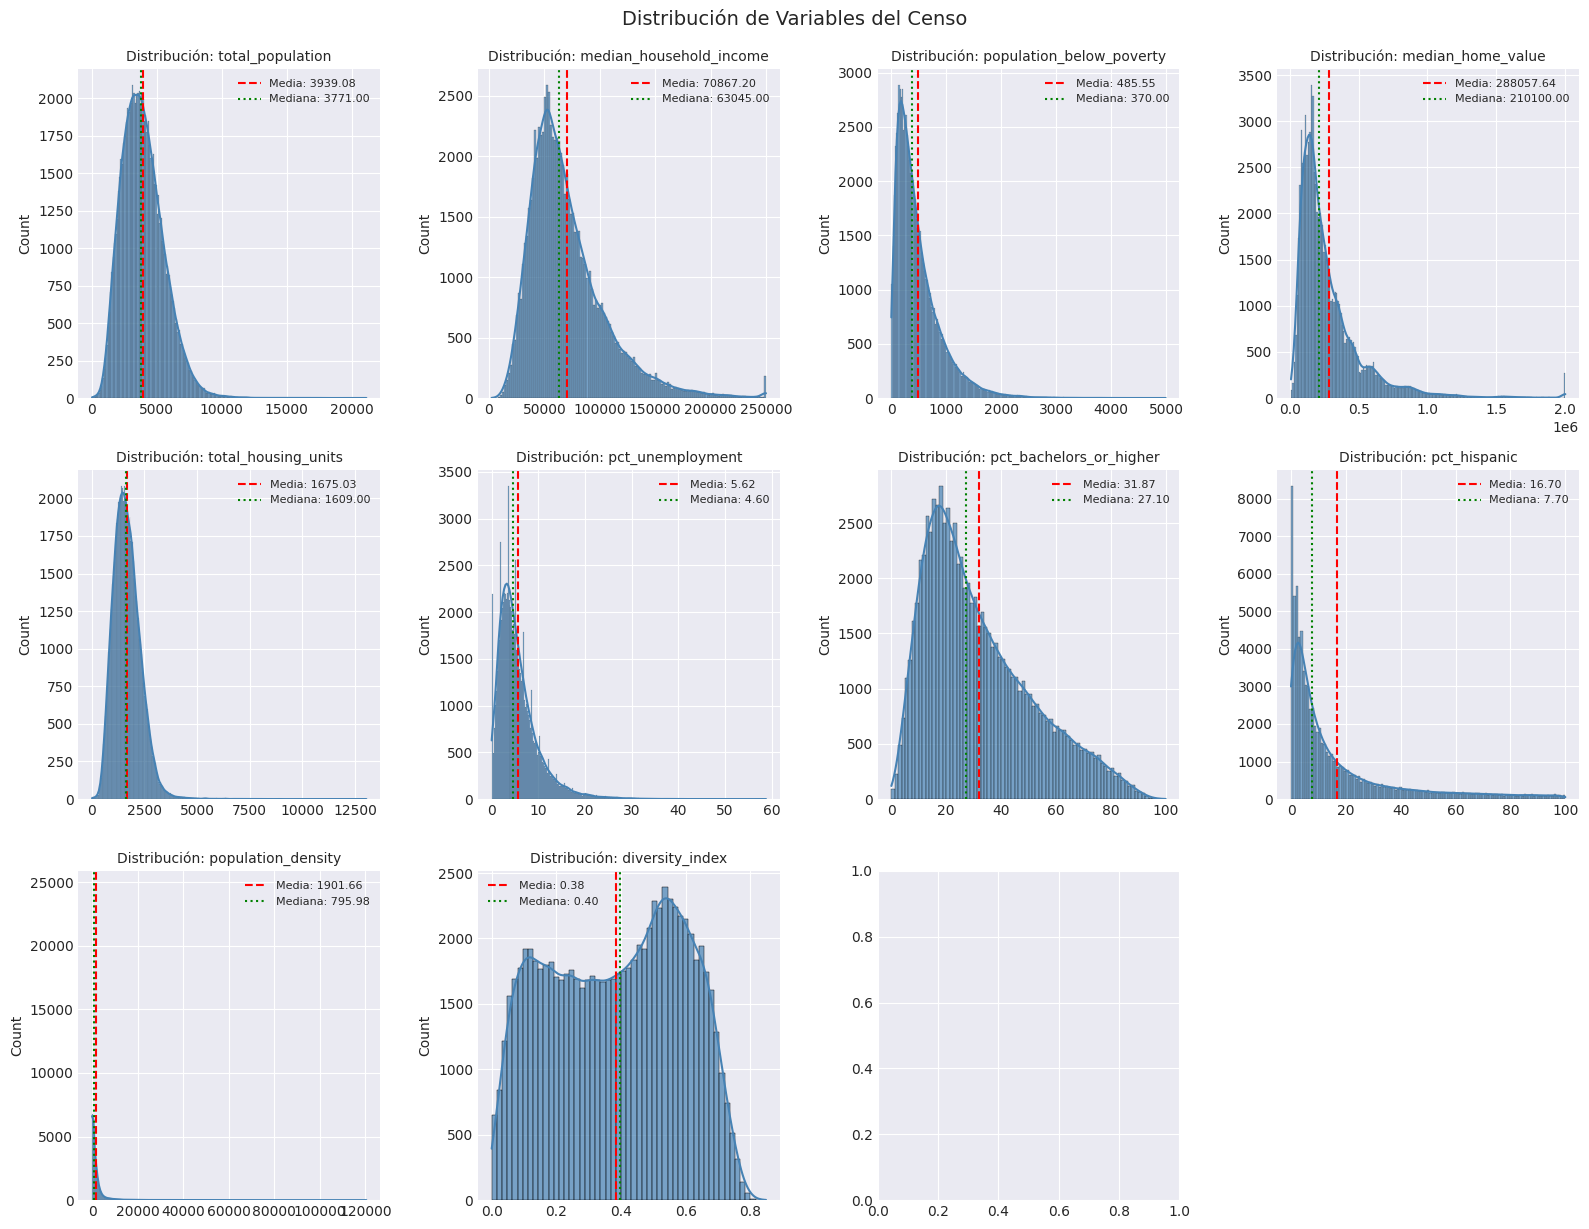

In [ ]:
# Distribution plots for key variables
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()
for idx, var in enumerate(analysis_vars):
    ax = axes[idx]
    data = analysis_clean[var].dropna()

    sns.histplot(data, kde=True, ax=ax, color='steelblue', alpha=0.7)
    ax.set_title(f'Distribución: {var}', fontsize=10)
    ax.set_xlabel('')

    # Add mean and median lines
    ax.axvline(data.mean(), color='red', linestyle='--', label=f'Media: {data.mean():.2f}')
    ax.axvline(data.median(), color='green', linestyle=':', label=f'Mediana: {data.median():.2f}')
    ax.legend(fontsize=8)
    
# Remove empty subplot
axes[-1].axis('off')
plt.tight_layout()
plt.suptitle('Distribución de Variables del Censo', y=1.02, fontsize=14)
plt.show()

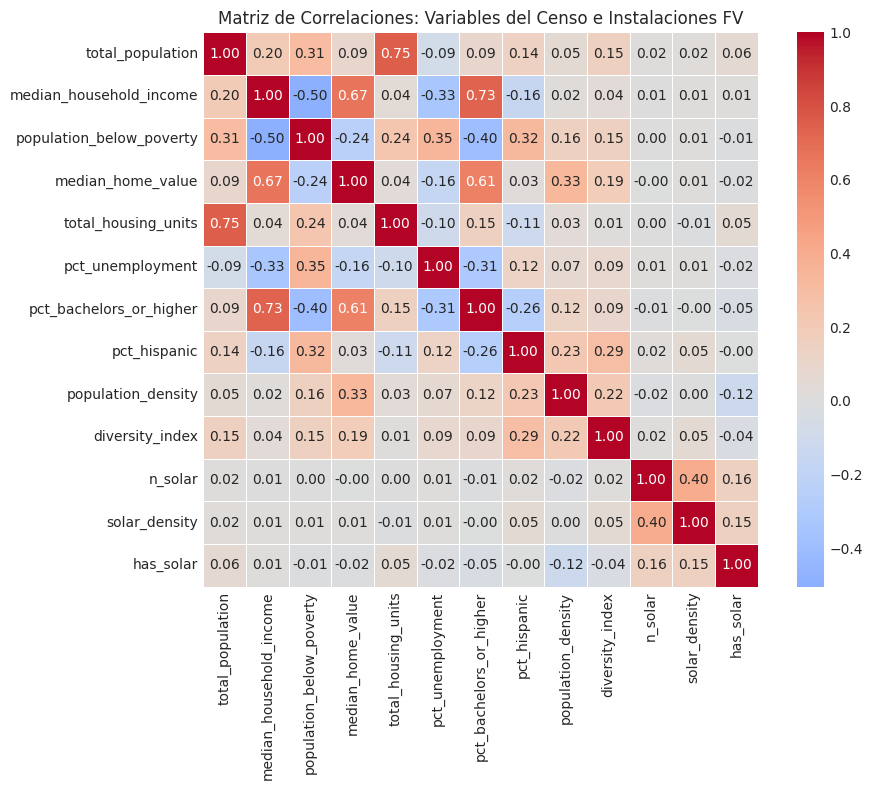

In [ ]:
# Correlation matrix
plt.figure(figsize=(10, 8))
corr_vars = analysis_vars + ['n_solar', 'solar_density', 'has_solar']
corr_matrix = analysis_clean[corr_vars].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            square=True, linewidths=0.5)
plt.title('Matriz de Correlaciones: Variables del Censo e Instalaciones FV')
plt.tight_layout()
plt.show()

### 3.4 Análisis de Clustering con HDBSCAN

Antes de las pruebas de hipótesis, realizamos clustering basado en densidad para descubrir patrones naturales en los datos de censo y solar. HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise) es preferido sobre K-Means porque:

1. **No requiere especificar el número de clusters a priori**: Detecta clusters automáticamente
2. **Robusto ante outliers**: Identifica puntos de ruido que no pertenecen a ningún cluster
3. **Detecta clusters de forma arbitraria**: No asume clusters esféricos como K-Means
4. **Basado en densidad**: Encuentra regiones de alta densidad separadas por regiones de baja densidad
5. **Jerárquico**: Proporciona una estructura de clustering a múltiples escalas

**Aplicación al análisis solar**: Identificamos grupos de census tracts con características socioeconómicas similares, luego comparamos estos clusters con la presencia/ausencia de instalaciones FV para entender qué perfiles demográficos están asociados con la adopción solar.

In [ ]:
# Import HDBSCAN and clustering utilities
try:
    from sklearn.cluster import HDBSCAN
    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA
    HDBSCAN_AVAILABLE = True
    print("✅ HDBSCAN (sklearn) disponible para análisis de clustering")
except ImportError:
    HDBSCAN_AVAILABLE = False
    print("⚠️ sklearn no instalado o versión antigua - clustering no disponible")
    print("   Para instalar: pip install scikit-learn")

✅ HDBSCAN (sklearn) disponible para análisis de clustering


In [ ]:
if HDBSCAN_AVAILABLE:
    # Select features for clustering: census + solar features (exclude LULC for now)
    cluster_features = [
        'total_population',
        'median_household_income',
        'population_below_poverty',
        'median_home_value',
        'total_housing_units',
        'pct_unemployment',
        'pct_bachelors_or_higher',
        'pct_hispanic',
        'population_density',
        'diversity_index',
        'solar_adoption_rate',
        'solar_density',
        'log_solar_count'
    ]
    
    print(f"🔍 Features para clustering: {len(cluster_features)}")
    for feat in cluster_features:
        print(f"   - {feat}")
    
    # Prepare clustering dataset
    cluster_df = analysis_clean[cluster_features].copy()
    
    # Standardize features (critical for distance-based clustering)
    scaler = StandardScaler()
    cluster_scaled = scaler.fit_transform(cluster_df)
    
    print(f"\n📊 Dataset de clustering:")
    print(f"   Observaciones: {len(cluster_df):,}")
    print(f"   Features: {len(cluster_features)}")
    print(f"   Transformación: StandardScaler (mean=0, std=1)")

🔍 Features para clustering: 13
   - total_population
   - median_household_income
   - population_below_poverty
   - median_home_value
   - total_housing_units
   - pct_unemployment
   - pct_bachelors_or_higher
   - pct_hispanic
   - population_density
   - diversity_index
   - solar_adoption_rate
   - solar_density
   - log_solar_count

📊 Dataset de clustering:
   Observaciones: 81,081
   Features: 13
   Transformación: StandardScaler (mean=0, std=1)


In [ ]:
if HDBSCAN_AVAILABLE:
    # Configure HDBSCAN parameters
    # min_cluster_size: minimum number of samples in a cluster
    # min_samples: controls how conservative clustering is (higher = more conservative)
    # cluster_selection_epsilon: distance threshold for merging clusters (0 = no merging)
    
    min_cluster_size = max(50, int(len(cluster_df) * 0.01))  # At least 1% of data or 50 points
    min_samples = max(10, int(min_cluster_size * 0.2))  # 20% of min_cluster_size
    
    print(f"\n⚙️ Configuración HDBSCAN:")
    print(f"   min_cluster_size: {min_cluster_size} (mínimo de puntos por cluster)")
    print(f"   min_samples: {min_samples} (controla conservadurismo del clustering)")
    print(f"   metric: euclidean")
    print(f"   cluster_selection_method: eom (Excess of Mass)")
    
    # Run HDBSCAN
    print(f"\n🔄 Ejecutando HDBSCAN...")
    clusterer = HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        metric='euclidean',
        cluster_selection_method='eom',
        n_jobs=-1  # Use all cores
    )
    
    cluster_labels = clusterer.fit_predict(cluster_scaled)
    
    # Add cluster labels to analysis dataframe
    analysis_clean['cluster'] = cluster_labels
    
    # Calculate clustering diagnostics
    n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    n_noise = list(cluster_labels).count(-1)
    pct_noise = (n_noise / len(cluster_labels)) * 100
    
    print(f"\n✅ Clustering completado:")
    print(f"   Clusters detectados: {n_clusters}")
    print(f"   Puntos de ruido: {n_noise:,} ({pct_noise:.1f}%)")
    print(f"   Puntos en clusters: {len(cluster_labels) - n_noise:,} ({100 - pct_noise:.1f}%)")
    
    # Show cluster size distribution
    if n_clusters > 0:
        cluster_sizes = pd.Series(cluster_labels[cluster_labels != -1]).value_counts().sort_index()
        print(f"\n📊 Distribución de tamaño de clusters:")
        for cluster_id, size in cluster_sizes.items():
            pct = (size / len(cluster_labels)) * 100
            print(f"   Cluster {cluster_id}: {size:,} tracts ({pct:.1f}%)")


⚙️ Configuración HDBSCAN:
   min_cluster_size: 810 (mínimo de puntos por cluster)
   min_samples: 162 (controla conservadurismo del clustering)
   metric: euclidean
   cluster_selection_method: eom (Excess of Mass)

🔄 Ejecutando HDBSCAN...

✅ Clustering completado:
   Clusters detectados: 2
   Puntos de ruido: 40,817 (50.3%)
   Puntos en clusters: 40,264 (49.7%)

📊 Distribución de tamaño de clusters:
   Cluster 0: 39,265 tracts (48.4%)
   Cluster 1: 999 tracts (1.2%)


In [ ]:
if HDBSCAN_AVAILABLE and n_clusters > 0:
    # Analyze cluster characteristics vs solar presence
    print(f"\n🔍 Características de clusters vs presencia de instalaciones FV:")
    
    cluster_solar_analysis = analysis_clean.groupby('cluster').agg({
        'has_solar': ['count', 'sum', 'mean'],
        'n_solar': 'sum',
        'total_population': 'mean',
        'median_household_income': 'mean',
        'median_home_value': 'mean',
        'pct_bachelors_or_higher': 'mean',
        'solar_adoption_rate': 'mean'
    }).round(2)
    
    # Flatten column names
    cluster_solar_analysis.columns = ['_'.join(col).strip() for col in cluster_solar_analysis.columns.values]
    cluster_solar_analysis = cluster_solar_analysis.rename(columns={
        'has_solar_count': 'n_tracts',
        'has_solar_sum': 'tracts_w_solar',
        'has_solar_mean': 'pct_w_solar',
        'n_solar_sum': 'total_installations'
    })
    
    display(cluster_solar_analysis)


🔍 Características de clusters vs presencia de instalaciones FV:


,n_tracts,tracts_w_solar,pct_w_solar,total_installations,total_population_mean,median_household_income_mean,median_home_value_mean,pct_bachelors_or_higher_mean,solar_adoption_rate_mean
cluster,,,,,,,,,
-1,40817,9334,0.23,69037,4218.05,75504.00,376297.42,34.96,1.17
0,39265,0,0.00,0,3659.23,66271.85,199791.49,28.94,0.00
1,999,999,1.00,1901,3540.14,62034.65,152009.11,21.05,1.21


In [ ]:
if HDBSCAN_AVAILABLE and n_clusters > 0:
    # PCA for 2D visualization
    print(f"\n🎨 Reducción de dimensionalidad para visualización (PCA)...")
    pca = PCA(n_components=2)
    cluster_pca = pca.fit_transform(cluster_scaled)
    
    explained_var = pca.explained_variance_ratio_
    print(f"   PC1 explica {explained_var[0]:.1%} de la varianza")
    print(f"   PC2 explica {explained_var[1]:.1%} de la varianza")
    print(f"   Total: {sum(explained_var):.1%}")
    
    # Add PCA components to analysis dataframe for plotting
    analysis_clean['pca_1'] = cluster_pca[:, 0]
    analysis_clean['pca_2'] = cluster_pca[:, 1]


🎨 Reducción de dimensionalidad para visualización (PCA)...
   PC1 explica 22.2% de la varianza
   PC2 explica 16.0% de la varianza
   Total: 38.2%


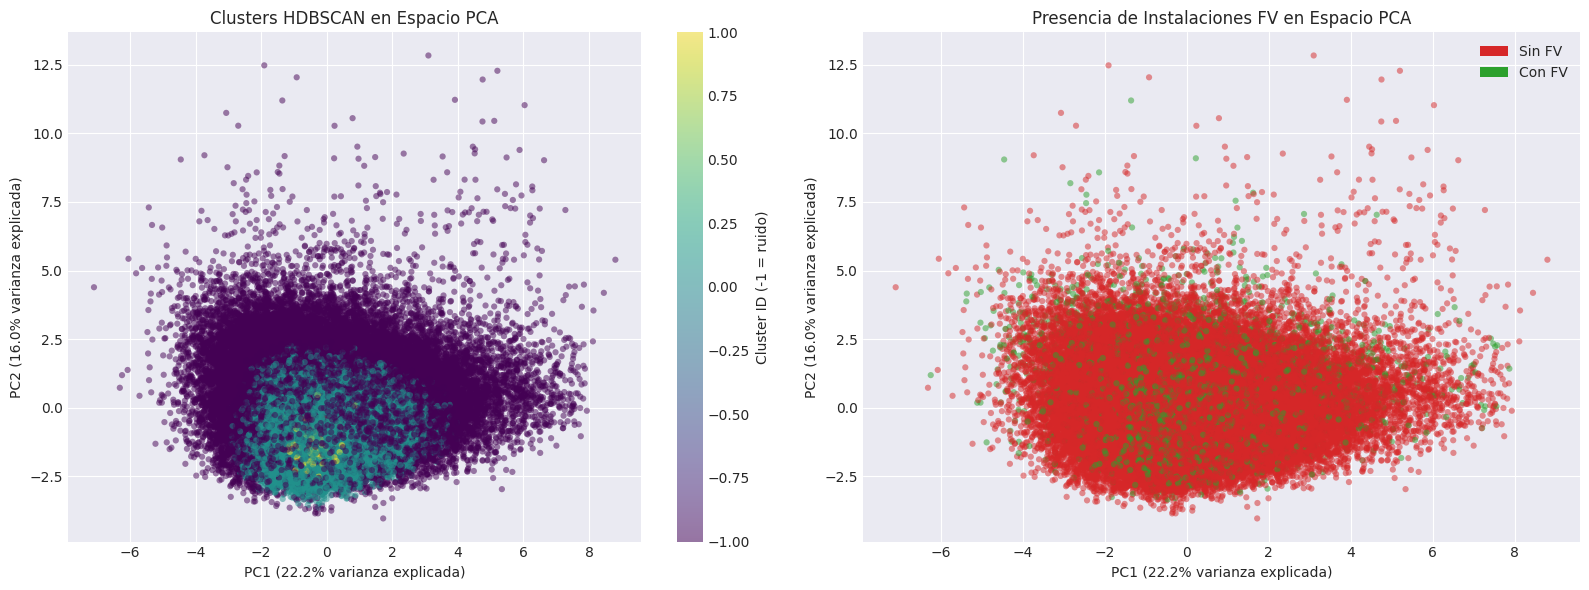

In [ ]:
if HDBSCAN_AVAILABLE and n_clusters > 0:
    # Visualization 1: Clusters colored by cluster ID
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Color by cluster
    scatter1 = ax1.scatter(
        analysis_clean['pca_1'],
        analysis_clean['pca_2'],
        c=analysis_clean['cluster'],
        cmap='viridis',
        alpha=0.5,
        s=20,
        edgecolors='none'
    )
    ax1.set_xlabel(f'PC1 ({explained_var[0]:.1%} varianza explicada)')
    ax1.set_ylabel(f'PC2 ({explained_var[1]:.1%} varianza explicada)')
    ax1.set_title('Clusters HDBSCAN en Espacio PCA')
    cbar1 = plt.colorbar(scatter1, ax=ax1)
    cbar1.set_label('Cluster ID (-1 = ruido)')
    
    # Plot 2: Color by solar presence
    colors = ['#d62728' if x == 0 else '#2ca02c' for x in analysis_clean['has_solar']]
    ax2.scatter(
        analysis_clean['pca_1'],
        analysis_clean['pca_2'],
        c=colors,
        alpha=0.5,
        s=20,
        edgecolors='none'
    )
    ax2.set_xlabel(f'PC1 ({explained_var[0]:.1%} varianza explicada)')
    ax2.set_ylabel(f'PC2 ({explained_var[1]:.1%} varianza explicada)')
    ax2.set_title('Presencia de Instalaciones FV en Espacio PCA')
    
    # Custom legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#d62728', label='Sin FV'),
        Patch(facecolor='#2ca02c', label='Con FV')
    ]
    ax2.legend(handles=legend_elements, loc='best')
    
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_4937/654212494.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




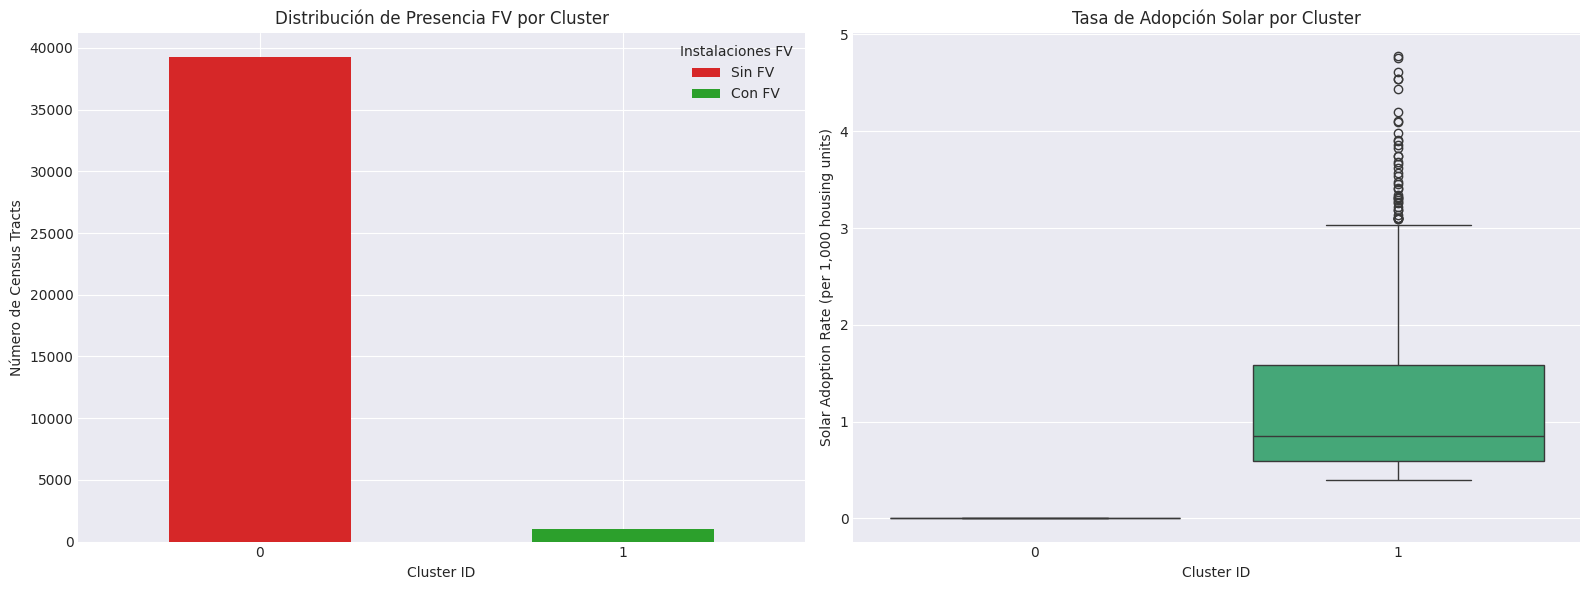

In [ ]:
if HDBSCAN_AVAILABLE and n_clusters > 0:
    # Visualization 2: Distribution of solar presence across clusters
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Stacked bar chart: solar presence by cluster
    cluster_solar_counts = analysis_clean[analysis_clean['cluster'] != -1].groupby(['cluster', 'has_solar']).size().unstack(fill_value=0)
    cluster_solar_counts.plot(kind='bar', stacked=True, ax=ax1, color=['#d62728', '#2ca02c'])
    ax1.set_xlabel('Cluster ID')
    ax1.set_ylabel('Número de Census Tracts')
    ax1.set_title('Distribución de Presencia FV por Cluster')
    ax1.legend(['Sin FV', 'Con FV'], title='Instalaciones FV')
    ax1.tick_params(axis='x', rotation=0)
    
    # Solar adoption rate by cluster (box plot)
    cluster_data_for_box = analysis_clean[analysis_clean['cluster'] != -1].copy()
    cluster_data_for_box['cluster'] = cluster_data_for_box['cluster'].astype(str)
    sns.boxplot(data=cluster_data_for_box, x='cluster', y='solar_adoption_rate', ax=ax2, palette='viridis')
    ax2.set_xlabel('Cluster ID')
    ax2.set_ylabel('Solar Adoption Rate (per 1,000 housing units)')
    ax2.set_title('Tasa de Adopción Solar por Cluster')
    ax2.tick_params(axis='x', rotation=0)
    
    plt.tight_layout()
    plt.show()

In [ ]:
if HDBSCAN_AVAILABLE and n_clusters > 0:
    # Statistical test: Are clusters associated with solar presence?
    # Use Chi-square test for independence
    from scipy.stats import chi2_contingency
    
    # Create contingency table (exclude noise points)
    clustered_data = analysis_clean[analysis_clean['cluster'] != -1].copy()
    contingency_table = pd.crosstab(clustered_data['cluster'], clustered_data['has_solar'])
    
    print(f"\n📊 Tabla de contingencia: Cluster vs Presencia FV")
    display(contingency_table)
    
    # Chi-square test
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    
    print(f"\n🔬 Test Chi-cuadrado de independencia:")
    print(f"   H₀: Los clusters son independientes de la presencia FV")
    print(f"   H₁: Los clusters están asociados con la presencia FV")
    print(f"   χ² = {chi2:E}")
    print(f"   p-value = {p_value:E}")
    print(f"   grados de libertad = {dof}")
    
    if p_value < 0.05:
        print(f"\n✅ RESULTADO: Rechazamos H₀ (p < 0.05)")
        print(f"   Los clusters están significativamente asociados con la presencia de instalaciones FV.")
    else:
        print(f"\n❌ RESULTADO: No rechazamos H₀ (p ≥ 0.05)")
        print(f"   No hay evidencia suficiente de asociación entre clusters y presencia FV.")
    
    # Cramér's V for effect size
    n = contingency_table.sum().sum()
    min_dim = min(contingency_table.shape[0], contingency_table.shape[1]) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim))
    
    print(f"\n📏 Tamaño del efecto (Cramér's V): {cramers_v:.4f}")
    if cramers_v < 0.1:
        effect_interpretation = "débil"
    elif cramers_v < 0.3:
        effect_interpretation = "moderado"
    else:
        effect_interpretation = "fuerte"
    print(f"   Interpretación: efecto {effect_interpretation}")


📊 Tabla de contingencia: Cluster vs Presencia FV


has_solar,0,1
cluster,,
0,39265,0
1,0,999



🔬 Test Chi-cuadrado de independencia:
   H₀: Los clusters son independientes de la presencia FV
   H₁: Los clusters están asociados con la presencia FV
   χ² = 4.022268E+04
   p-value = 0.000000E+00
   grados de libertad = 1

✅ RESULTADO: Rechazamos H₀ (p < 0.05)
   Los clusters están significativamente asociados con la presencia de instalaciones FV.

📏 Tamaño del efecto (Cramér's V): 0.9995
   Interpretación: efecto fuerte


In [ ]:
if HDBSCAN_AVAILABLE and n_clusters > 0:
    # Feature importance: Which features differentiate clusters?
    # Calculate mean and std for each feature by cluster
    print(f"\n🔍 Características distintivas de cada cluster:")
    print("=" * 80)
    
    for cluster_id in sorted(analysis_clean['cluster'].unique()):
        if cluster_id == -1:
            continue  # Skip noise
        
        cluster_data = analysis_clean[analysis_clean['cluster'] == cluster_id]
        n_tracts = len(cluster_data)
        pct_with_solar = cluster_data['has_solar'].mean() * 100
        
        print(f"\n📌 Cluster {cluster_id} (n={n_tracts:,}, {pct_with_solar:.1f}% con FV):")
        
        # Show key characteristics (z-scores relative to overall mean)
        for feat in ['median_household_income', 'median_home_value', 'pct_bachelors_or_higher', 
                     'total_population', 'solar_adoption_rate']:
            cluster_mean = cluster_data[feat].mean()
            overall_mean = analysis_clean[feat].mean()
            overall_std = analysis_clean[feat].std()
            z_score = (cluster_mean - overall_mean) / overall_std
            
            print(f"   {feat}: {cluster_mean:.2f} (z={z_score:+.2f})")


🔍 Características distintivas de cada cluster:

📌 Cluster 0 (n=39,265, 0.0% con FV):
   median_household_income: 66271.85 (z=-0.13)
   median_home_value: 199791.49 (z=-0.35)
   pct_bachelors_or_higher: 28.94 (z=-0.15)
   total_population: 3659.23 (z=-0.17)
   solar_adoption_rate: 0.00 (z=-0.05)

📌 Cluster 1 (n=999, 100.0% con FV):
   median_household_income: 62034.65 (z=-0.25)
   median_home_value: 152009.11 (z=-0.54)
   pct_bachelors_or_higher: 21.05 (z=-0.55)
   total_population: 3540.14 (z=-0.25)
   solar_adoption_rate: 1.21 (z=+0.05)


### 3.4.1 Spatial Clustering of Solar Installations (Lat/Lon)

To complement the socio-economic clustering, we perform spatial clustering using the geographic coordinates (latitude/longitude) of the **individual PV installations**. This helps identify spatial "hotspots" of solar adoption that may not be explained solely by socio-economic factors.

We use the **Haversine metric** with HDBSCAN, which calculates distances between points on a sphere (Earth), requiring coordinates in **radians**.

In [ ]:
if HDBSCAN_AVAILABLE:
    print("\n🌍 Spatial Clustering (Lat/Lon) with Haversine Metric")
    print("=" * 80)
    
    # Use the original PV dataset with individual installation coordinates
    # pv_census_df contains 'centroid_lat' and 'centroid_lon' for each installation
    spatial_data = pv_census_df[['centroid_lat', 'centroid_lon', 'dataset_name']].copy()
    
    # Drop any missing coordinates
    spatial_data = spatial_data.dropna(subset=['centroid_lat', 'centroid_lon'])
    
    print(f"   Clustering {len(spatial_data):,} individual PV installations...")
    
    # Convert to radians for Haversine metric
    spatial_data['lat_rad'] = np.radians(spatial_data['centroid_lat'])
    spatial_data['lon_rad'] = np.radians(spatial_data['centroid_lon'])
    
    spatial_features = spatial_data[['lat_rad', 'lon_rad']].values
    
    # Configure HDBSCAN for spatial clustering
    # min_cluster_size: minimum number of installations to form a spatial cluster
    # cluster_selection_epsilon: distance threshold (in radians)
    # For haversine, epsilon is in radians. 
    # Earth radius ~ 6371 km. 10 km ~ 10/6371 radians ~ 0.0015
    
    # Since we have many more points now (installations vs tracts), we adjust parameters
    # Use a sample if dataset is extremely large (>100k) to keep runtime reasonable for demo
    if len(spatial_data) > 100000:
        print(f"   ⚠️ Dataset large ({len(spatial_data):,}), using random sample of 100,000 for clustering...")
        spatial_sample = spatial_data.sample(n=100000, random_state=42)
    else:
        spatial_sample = spatial_data
        
    spatial_features_sample = spatial_sample[['lat_rad', 'lon_rad']].values
    
    spatial_clusterer = HDBSCAN(
        min_cluster_size=max(50, int(len(spatial_sample) * 0.001)), # 0.1% or 50 points
        min_samples=15,
        metric='haversine',
        cluster_selection_method='eom',
        n_jobs=-1
    )
    
    print(f"   Running HDBSCAN on {len(spatial_sample):,} points...")
    spatial_labels = spatial_clusterer.fit_predict(spatial_features_sample)
    
    spatial_sample['spatial_cluster'] = spatial_labels
    
    n_spatial_clusters = len(set(spatial_labels)) - (1 if -1 in spatial_labels else 0)
    print(f"   ✅ Spatial clusters detected: {n_spatial_clusters}")
    
    # Visualize spatial clusters
    # Use a smaller sample for plotting if still very large
    plot_data = spatial_sample if len(spatial_sample) < 20000 else spatial_sample.sample(20000)
    
    fig = px.scatter_map(
        plot_data,
        lat='centroid_lat',
        lon='centroid_lon',
        color='spatial_cluster',
        hover_name='dataset_name',
        zoom=3,
        height=600,
        title=f'Spatial Clusters of Individual PV Installations (HDBSCAN Haversine) - {n_spatial_clusters} Clusters'
    )
    # fig.update_layout(mapbox_style="carto-positron")
    fig.show()
    
else:
    print("   ⚠️ HDBSCAN not available.")


🌍 Spatial Clustering (Lat/Lon) with Haversine Metric
   Clustering 73,165 individual PV installations...
   Running HDBSCAN on 73,165 points...
   ✅ Spatial clusters detected: 240


### 3.5 Pruebas de Normalidad

Antes de seleccionar las pruebas estadísticas apropiadas, debemos verificar si nuestras variables siguen una distribución normal. Utilizamos:

1. **Q-Q Plots**: Visualización gráfica
2. **Shapiro-Wilk Test**: Prueba estadística (mejor para n < 5000)
3. **Kolmogorov-Smirnov Test**: Prueba estadística (para muestras grandes)

**Interpretación de p-value:**
- p > 0.05: No rechazamos H₀ → Los datos podrían ser normales
- p ≤ 0.05: Rechazamos H₀ → Los datos NO son normales

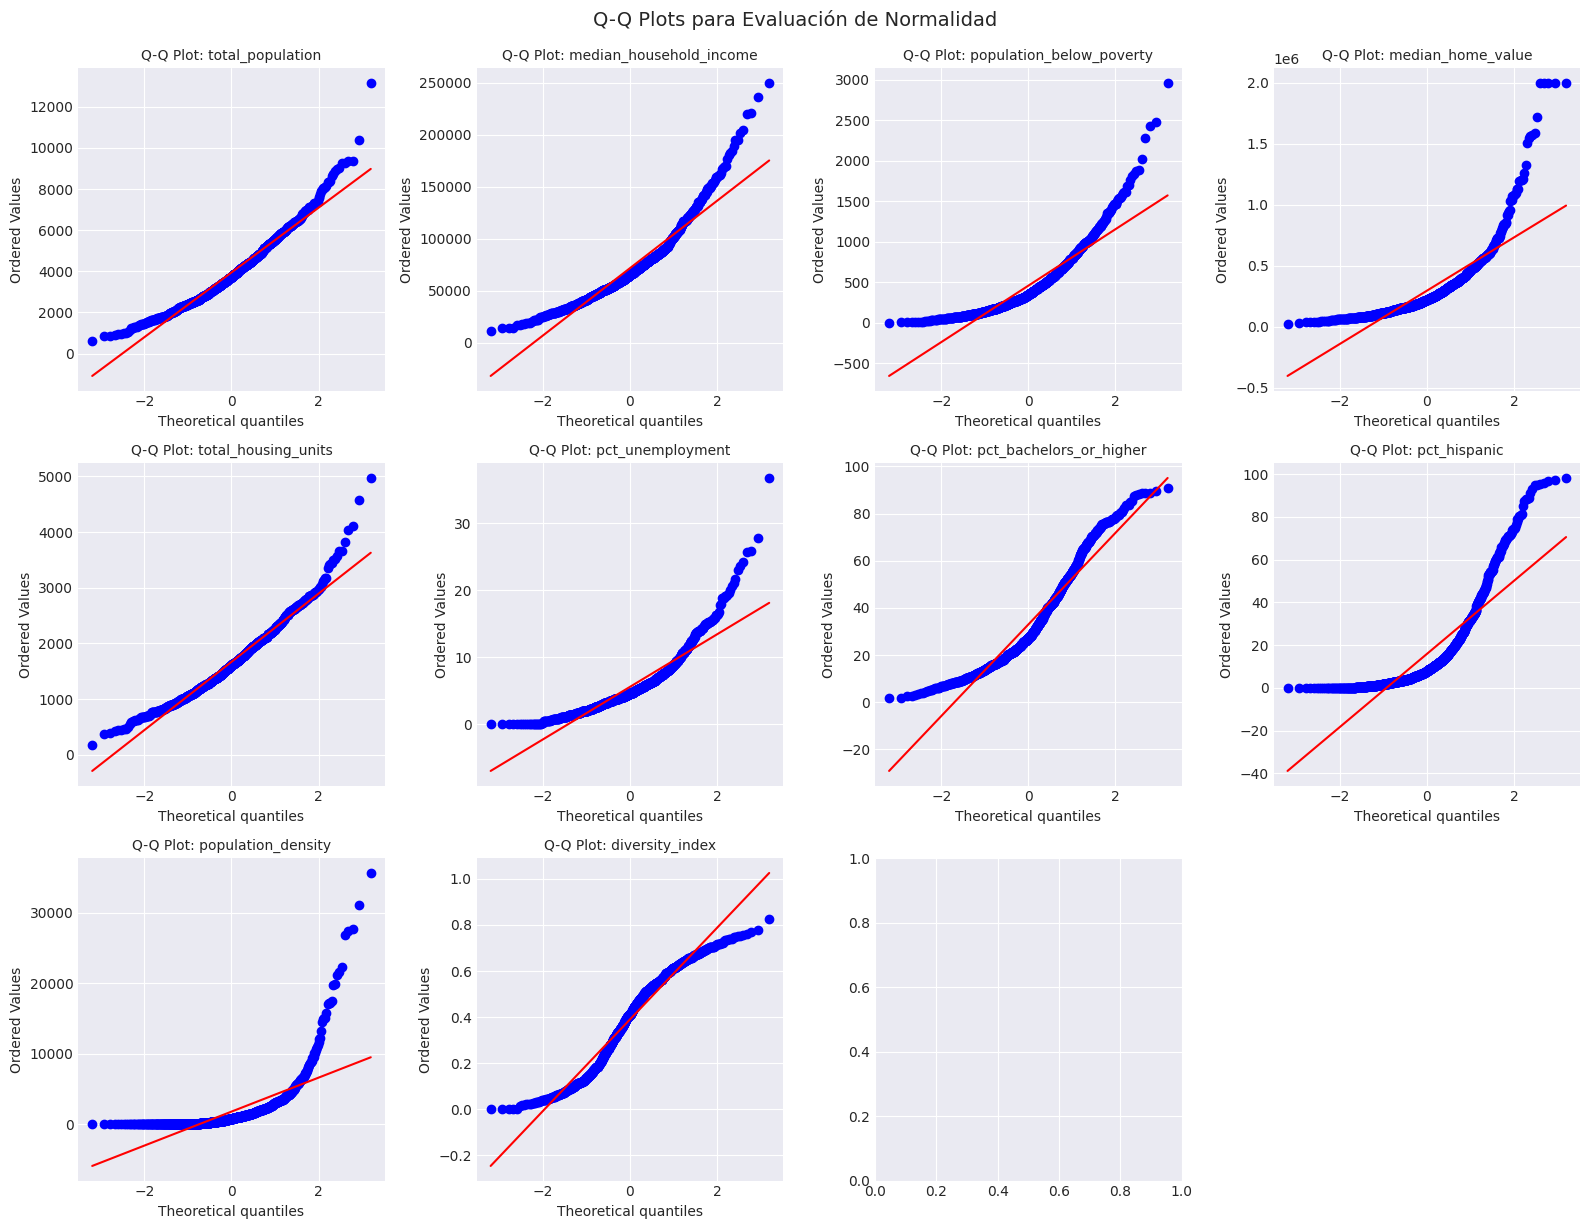

In [ ]:
# Q-Q Plots for normality assessment
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()
for idx, var in enumerate(analysis_vars):
    ax = axes[idx]
    data = analysis_clean[var].dropna()

    # Use a sample if data is too large for visualization
    sample_data = data.sample(n=min(1000, len(data)), random_state=42)

    stats.probplot(sample_data, dist="norm", plot=ax)
    ax.set_title(f'Q-Q Plot: {var}', fontsize=10)


axes[-1].axis('off')
plt.tight_layout()
plt.suptitle('Q-Q Plots para Evaluación de Normalidad', y=1.02, fontsize=14)
plt.show()

In [ ]:
# Statistical normality tests
print("📊 Pruebas de Normalidad para Variables del Censo")
print("=" * 80)
print(f"{'Variable':<30} {'Shapiro-Wilk':<20} {'Kolmogorov-Smirnov':<20} {'Normal?'}")
print("-" * 80)
normality_results = []

for var in analysis_vars:
    data = analysis_clean[var].dropna()

    # Shapiro-Wilk test (use sample for large datasets)
    sample_size = min(5000, len(data))
    sample = data.sample(n=sample_size, random_state=42)
    shapiro_stat, shapiro_p = stats.shapiro(sample)

    # Kolmogorov-Smirnov test
    # Standardize data for K-S test against standard normal
    standardized = (data - data.mean()) / data.std()
    ks_stat, ks_p = stats.kstest(standardized, 'norm')

    is_normal = "Sí" if (shapiro_p > 0.05 and ks_p > 0.05) else "No"

    normality_results.append({
        'variable': var,
        'shapiro_stat': shapiro_stat,
        'shapiro_p': shapiro_p,
        'ks_stat': ks_stat,
        'ks_p': ks_p,
        'is_normal': is_normal == "Sí"
    })

    print(f"{var:<30} p={shapiro_p:.4f}  {'✓' if shapiro_p > 0.05 else '✗'}     p={ks_p:.4f}  {'✓' if ks_p > 0.05 else '✗'}      {is_normal}")

print("-" * 80)
print("Nota: ✓ indica p > 0.05 (no se rechaza normalidad), ✗ indica p ≤ 0.05 (se rechaza normalidad)")
normality_df = pd.DataFrame(normality_results)

📊 Pruebas de Normalidad para Variables del Censo
Variable                       Shapiro-Wilk         Kolmogorov-Smirnov   Normal?
--------------------------------------------------------------------------------
total_population               p=0.0000  ✗     p=0.0000  ✗      No
median_household_income        p=0.0000  ✗     p=0.0000  ✗      No
population_below_poverty       p=0.0000  ✗     p=0.0000  ✗      No
median_home_value              p=0.0000  ✗     p=0.0000  ✗      No
total_housing_units            p=0.0000  ✗     p=0.0000  ✗      No
pct_unemployment               p=0.0000  ✗     p=0.0000  ✗      No
pct_bachelors_or_higher        p=0.0000  ✗     p=0.0000  ✗      No
pct_hispanic                   p=0.0000  ✗     p=0.0000  ✗      No
population_density             p=0.0000  ✗     p=0.0000  ✗      No
diversity_index                p=0.0000  ✗     p=0.0000  ✗      No
--------------------------------------------------------------------------------
Nota: ✓ indica p > 0.05 (no se rechaza

### 3.5 Análisis de Poder Estadístico

El análisis de poder nos ayuda a determinar si tenemos suficientes observaciones para detectar efectos estadísticamente significativos.

**Conceptos clave:**
- **Effect Size (Cohen's d)**: Magnitud del efecto (pequeño=0.2, mediano=0.5, grande=0.8)
- **Alpha (α)**: Probabilidad de error Tipo I (falso positivo) - típicamente 0.05
- **Power (1-β)**: Probabilidad de detectar un efecto verdadero - típicamente 0.80
- **Sample Size (n)**: Número de observaciones necesarias

In [ ]:
# Power Analysis
print("📊 Análisis de Poder Estadístico")
print("=" * 60)
# Get sample sizes for our two groups
n_with_solar = analysis_clean['has_solar'].sum()
n_without_solar = len(analysis_clean) - n_with_solar
print(f"\nTamaños de muestra actuales:")
print(f"   Tracts CON instalaciones FV (n₁): {n_with_solar:,}")
print(f"   Tracts SIN instalaciones FV (n₂): {n_without_solar:,}")
print(f"   Ratio n₂/n₁: {n_without_solar/n_with_solar:.2f}")

📊 Análisis de Poder Estadístico

Tamaños de muestra actuales:
   Tracts CON instalaciones FV (n₁): 10,333
   Tracts SIN instalaciones FV (n₂): 70,748
   Ratio n₂/n₁: 6.85


In [ ]:
# Calculate required sample sizes for different effect sizes
effect_sizes = [0.2, 0.5, 0.8]
alpha = 0.05
power = 0.80

print(f"\n📐 Tamaño de muestra requerido por grupo (α={alpha}, power={power}):")
print("-" * 60)
for es in effect_sizes:
    required_n = smp.tt_ind_solve_power(
        effect_size=es,
        nobs1=None,
        alpha=alpha,
        power=power,
        ratio=1,
        alternative='two-sided'
    )
    size_label = "pequeño" if es == 0.2 else ("mediano" if es == 0.5 else "grande")
    meets_req = "✓" if min(n_with_solar, n_without_solar) >= required_n else "✗"
    print(f"   Effect size {es} ({size_label}): n = {round(required_n):,} por grupo {meets_req}")


📐 Tamaño de muestra requerido por grupo (α=0.05, power=0.8):
------------------------------------------------------------
   Effect size 0.2 (pequeño): n = 393 por grupo ✓
   Effect size 0.5 (mediano): n = 64 por grupo ✓
   Effect size 0.8 (grande): n = 26 por grupo ✓


In [ ]:
# Calculate actual power with our sample sizes
print(f"\n📈 Poder estadístico con nuestros tamaños de muestra actuales:")
print("-" * 60)
for es in effect_sizes:
    actual_power = smp.tt_ind_solve_power(
        effect_size=es,
        nobs1=n_with_solar,
        alpha=alpha,
        power=None,
        ratio=n_without_solar/n_with_solar,
        alternative='two-sided'
    )
    size_label = "pequeño" if es == 0.2 else ("mediano" if es == 0.5 else "grande")
    print(f"   Effect size {es} ({size_label}): power = {actual_power:.4f} ({actual_power*100:.1f}%)")


📈 Poder estadístico con nuestros tamaños de muestra actuales:
------------------------------------------------------------
   Effect size 0.2 (pequeño): power = 1.0000 (100.0%)
   Effect size 0.5 (mediano): power = 1.0000 (100.0%)
   Effect size 0.8 (grande): power = 1.0000 (100.0%)


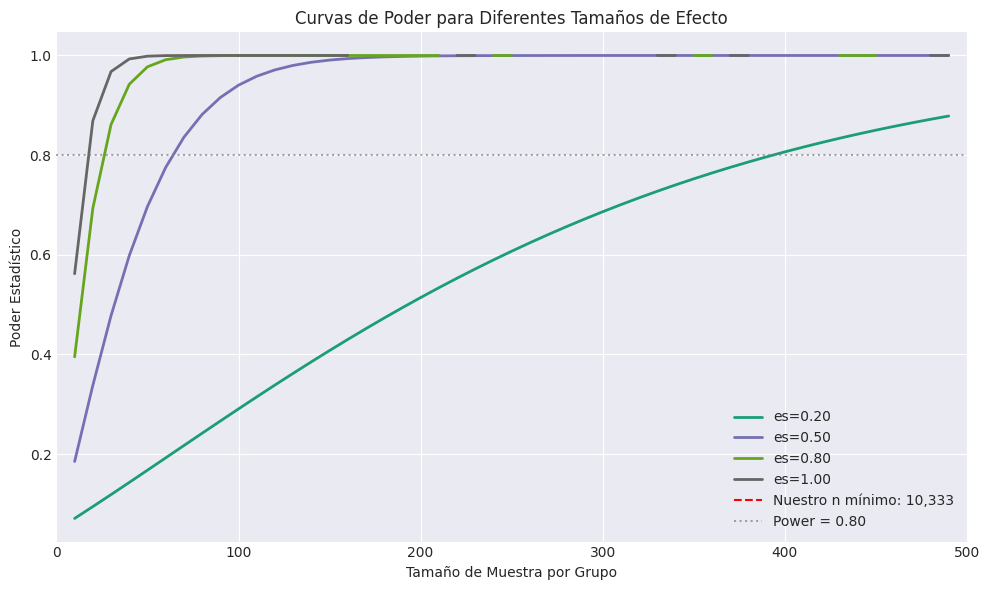

In [ ]:
# Power curves visualization
fig, ax = plt.subplots(figsize=(10, 6))
effect_sizes_range = np.array([0.2, 0.5, 0.8, 1.0])
sample_sizes_range = np.arange(10, 500, 10)
power_obj = smp.TTestIndPower()
power_obj.plot_power(dep_var='nobs', nobs=sample_sizes_range, effect_size=effect_sizes_range, ax=ax)
# Add vertical line for our smallest group
ax.axvline(x=min(n_with_solar, n_without_solar), color='red', linestyle='--',
           label=f'Nuestro n mínimo: {min(n_with_solar, n_without_solar):,}')
ax.axhline(y=0.8, color='gray', linestyle=':', alpha=0.7, label='Power = 0.80')

ax.set_xlabel("Tamaño de Muestra por Grupo")
ax.set_ylabel("Poder Estadístico")
ax.set_title("Curvas de Poder para Diferentes Tamaños de Efecto")
ax.legend(loc='lower right')
ax.set_xlim(0, 500)
plt.tight_layout()
plt.show()

In [ ]:
print("\n💡 Interpretación:")
print("   Con nuestros tamaños de muestra, tenemos poder estadístico suficiente")
print("   para detectar efectos pequeños (d=0.2) con alta confiabilidad.")


💡 Interpretación:
   Con nuestros tamaños de muestra, tenemos poder estadístico suficiente
   para detectar efectos pequeños (d=0.2) con alta confiabilidad.


## 📈 4: Pruebas Estadísticas de Diferencias entre Grupos

Ahora que hemos verificado la normalidad (o falta de ella) de nuestras variables y confirmado que tenemos poder estadístico suficiente, realizamos las pruebas para determinar si existen diferencias significativas entre:

- **Grupo 1**: Census tracts CON instalaciones fotovoltaicas
- **Grupo 2**: Census tracts SIN instalaciones fotovoltaicas

### Selección de Prueba
- Si los datos son **normales**: t-test independiente
- Si los datos **NO son normales**: Mann-Whitney U (no paramétrica)

Basado en nuestros resultados de normalidad, utilizaremos **Mann-Whitney U** para la mayoría de las variables.

In [ ]:
# Compare groups: with vs without solar installations
print("📊 Comparación de Grupos: Tracts con vs sin Instalaciones FV")
print("=" * 80)
# Split data into two groups
group_with_solar = analysis_clean[analysis_clean['has_solar'] == 1]
group_without_solar = analysis_clean[analysis_clean['has_solar'] == 0]
print(f"\nEstadísticas descriptivas por grupo:")
print("-" * 80)
comparison_results = []

for var in analysis_vars:
    data_with = group_with_solar[var].dropna()
    data_without = group_without_solar[var].dropna()

    # Calculate means and medians
    mean_with = data_with.mean()
    mean_without = data_without.mean()
    median_with = data_with.median()
    median_without = data_without.median()

    # Determine which test to use based on normality
    var_is_normal = normality_df[normality_df['variable'] == var]['is_normal'].values[0]

    if var_is_normal:
        # Use independent t-test
        stat, p_value = stats.ttest_ind(data_with, data_without)
        test_name = "t-test"
    else:
        # Use Mann-Whitney U test
        stat, p_value = stats.mannwhitneyu(data_with, data_without, alternative='two-sided')
        test_name = "Mann-Whitney U"

    # Effect size (Cohen's d)
    pooled_std = np.sqrt(((len(data_with)-1)*data_with.std()**2 + (len(data_without)-1)*data_without.std()**2) /
                         (len(data_with) + len(data_without) - 2))
    cohens_d = (mean_with - mean_without) / pooled_std if pooled_std > 0 else 0

    sig = "***" if p_value < 0.001 else ("**" if p_value < 0.01 else ("*" if p_value < 0.05 else ""))

    comparison_results.append({
        'variable': var,
        'mean_with_solar': mean_with,
        'mean_without_solar': mean_without,
        'median_with_solar': median_with,
        'median_without_solar': median_without,
        'test': test_name,
        'statistic': stat,
        'p_value': p_value,
        'cohens_d': cohens_d,
        'significant': p_value < 0.05
    })

# Display results as DataFrame
results_df = pd.DataFrame(comparison_results)
print("\n📋 Resultados de las Pruebas Estadísticas:")
display(results_df[['variable', 'mean_with_solar', 'mean_without_solar', 'test', 'p_value', 'cohens_d', 'significant']])

📊 Comparación de Grupos: Tracts con vs sin Instalaciones FV

Estadísticas descriptivas por grupo:
--------------------------------------------------------------------------------

📋 Resultados de las Pruebas Estadísticas:


,variable,mean_with_solar,mean_without_solar,test,p_value,cohens_d,significant
0,total_population,4197.509629,3901.330257,Mann-Whitney U,3.472808e-67,0.184714,True
1,median_household_income,71931.827736,70711.711554,Mann-Whitney U,2.638940e-15,0.034956,True
2,population_below_poverty,477.827640,486.673065,Mann-Whitney U,7.486502e-01,-0.021274,False
3,median_home_value,277871.172070,289545.410782,Mann-Whitney U,2.200717e-01,-0.045923,False
4,total_housing_units,1763.574373,1662.098787,Mann-Whitney U,5.197530e-56,0.157243,True
5,pct_unemployment,5.381303,5.656060,Mann-Whitney U,1.940690e-05,-0.062125,True
6,pct_bachelors_or_higher,29.504916,32.215656,Mann-Whitney U,2.544151e-29,-0.138705,True
7,pct_hispanic,16.677586,16.703956,Mann-Whitney U,8.069821e-02,-0.001223,False
8,population_density,608.980900,2090.465430,Mann-Whitney U,0.000000e+00,-0.362532,True
9,diversity_index,0.364151,0.387046,Mann-Whitney U,1.392841e-26,-0.112866,True


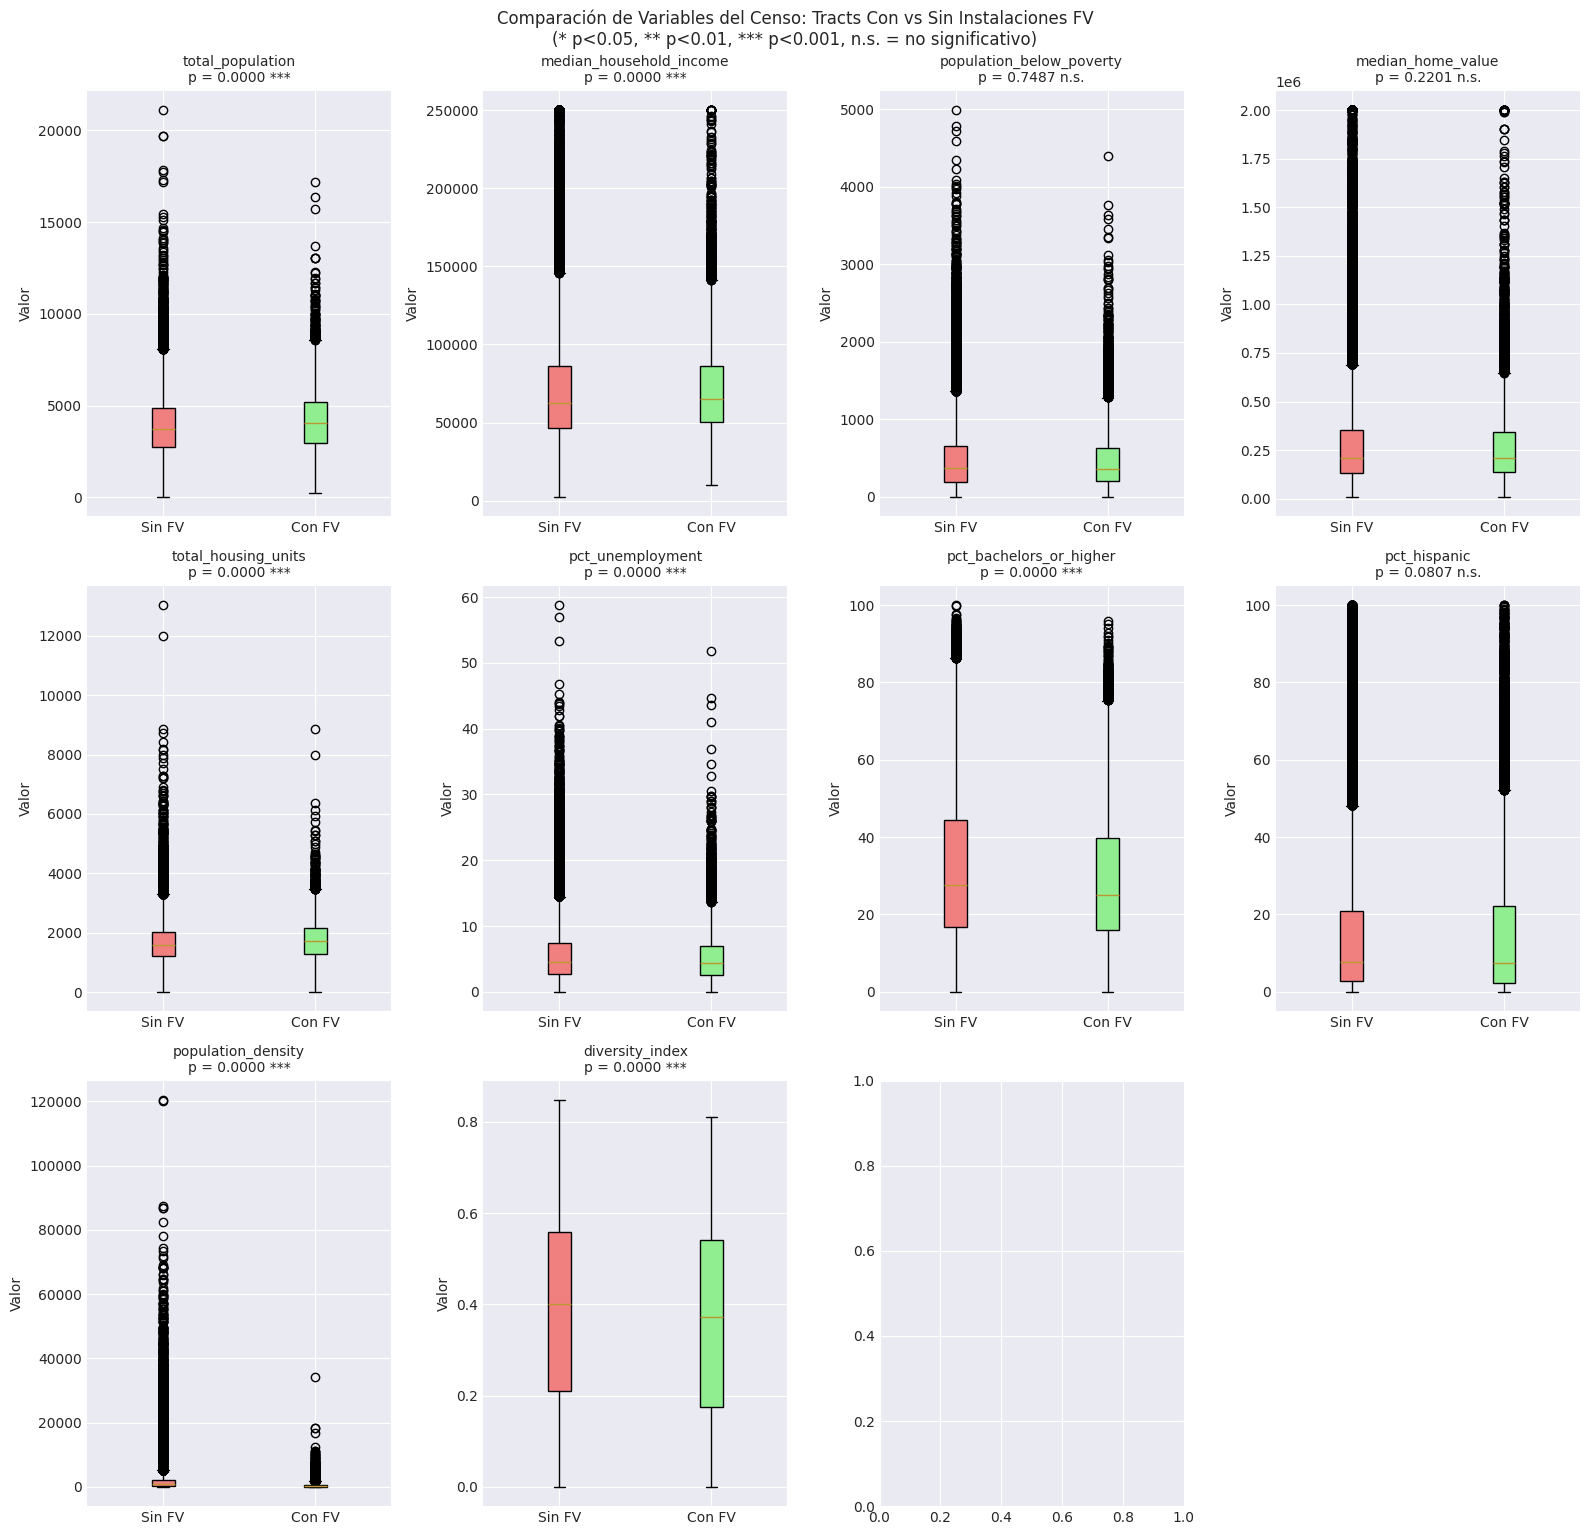

In [ ]:
# Visualize group comparisons
fig, axes = plt.subplots(3, 4, figsize=(16, 15))
axes = axes.flatten()

for idx, var in enumerate(analysis_vars):
    ax = axes[idx]

    # Prepare data for boxplot
    data_with = group_with_solar[var].dropna()
    data_without = group_without_solar[var].dropna()

    # Create boxplot
    box_data = [data_without, data_with]
    bp = ax.boxplot(box_data, tick_labels=['Sin FV', 'Con FV'], patch_artist=True)

    # Color the boxes
    bp['boxes'][0].set_facecolor('lightcoral')
    bp['boxes'][1].set_facecolor('lightgreen')

    # Get p-value for title
    p_val = results_df[results_df['variable'] == var]['p_value'].values[0]
    sig_marker = "***" if p_val < 0.001 else ("**" if p_val < 0.01 else ("*" if p_val < 0.05 else "n.s."))

    ax.set_title(f'{var}\np = {p_val:.4f} {sig_marker}', fontsize=10)
    ax.set_ylabel('Valor')

axes[-1].axis('off')
plt.tight_layout()
plt.suptitle('Comparación de Variables del Censo: Tracts Con vs Sin Instalaciones FV\n(* p<0.05, ** p<0.01, *** p<0.001, n.s. = no significativo)',
             y=1.02, fontsize=12)
plt.show()

In [ ]:
# Summary of significant differences
print("\n📊 Resumen de Diferencias Significativas (p < 0.05):")
print("=" * 60)
sig_results = results_df[results_df['significant']]
if len(sig_results) > 0:
    for _, row in sig_results.iterrows():
        direction = "mayor" if row['mean_with_solar'] > row['mean_without_solar'] else "menor"
        effect_size = "pequeño" if abs(row['cohens_d']) < 0.5 else ("mediano" if abs(row['cohens_d']) < 0.8 else "grande")
        print(f"\n   📍 {row['variable']}:")
        print(f"      - Los tracts CON instalaciones FV tienen un valor {direction}")
        print(f"      - Media con FV: {row['mean_with_solar']:.2f} vs sin FV: {row['mean_without_solar']:.2f}")
        print(f"      - Tamaño del efecto (Cohen's d): {row['cohens_d']:.3f} ({effect_size})")
        print(f"      - p-value: {row['p_value']:E}")
else:
    print("   No se encontraron diferencias estadísticamente significativas.")

print("\n💡 Nota: Estas diferencias sugieren patrones en la adopción de energía solar")
print("   en relación con características socioeconómicas de los census tracts.")


📊 Resumen de Diferencias Significativas (p < 0.05):

   📍 total_population:
      - Los tracts CON instalaciones FV tienen un valor mayor
      - Media con FV: 4197.51 vs sin FV: 3901.33
      - Tamaño del efecto (Cohen's d): 0.185 (pequeño)
      - p-value: 3.472808E-67

   📍 median_household_income:
      - Los tracts CON instalaciones FV tienen un valor mayor
      - Media con FV: 71931.83 vs sin FV: 70711.71
      - Tamaño del efecto (Cohen's d): 0.035 (pequeño)
      - p-value: 2.638940E-15

   📍 total_housing_units:
      - Los tracts CON instalaciones FV tienen un valor mayor
      - Media con FV: 1763.57 vs sin FV: 1662.10
      - Tamaño del efecto (Cohen's d): 0.157 (pequeño)
      - p-value: 5.197530E-56

   📍 pct_unemployment:
      - Los tracts CON instalaciones FV tienen un valor menor
      - Media con FV: 5.38 vs sin FV: 5.66
      - Tamaño del efecto (Cohen's d): -0.062 (pequeño)
      - p-value: 1.940690E-05

   📍 pct_bachelors_or_higher:
      - Los tracts CON instal

### 4.2 Modelos de Regresión

Complementamos el análisis de diferencias de grupos con modelos de regresión para entender las relaciones entre variables socioeconómicas y la adopción solar. Implementamos tres tipos de modelos:

1. **Regresión Logística**: Predice presencia/ausencia de instalaciones FV (variable binaria `has_solar`)
2. **Regresión Lineal**: Modela la tasa de adopción solar (`solar_adoption_rate` - continua)
3. **Regresión de Poisson**: Modela el conteo de instalaciones (`n_solar` - datos de conteo)

Cada modelo responde a diferentes preguntas de investigación y es apropiado para diferentes tipos de variables dependientes.

#### 4.2.1 Regresión Logística: Presencia de Instalaciones FV

**Pregunta de investigación**: ¿Qué factores socioeconómicos predicen la presencia (sí/no) de instalaciones solares en un census tract?

**Variable dependiente**: `has_solar` (binaria: 1 = tiene FV, 0 = no tiene FV)

**Métricas**:
- **Odds Ratio**: Cuánto cambian las probabilidades por cambio en predictor
- **p-value**: Significancia estadística del predictor
- **Pseudo-R²** (McFadden): Ajuste del modelo (0-1, mayor es mejor)
- **AIC/BIC**: Criterios de información (menor es mejor)

In [ ]:
import statsmodels.formula.api as smf

# Prepare data for logistic regression (drop any remaining NaN)
logit_data = analysis_clean[['has_solar'] + analysis_vars].dropna()

# Standardize predictors for better coefficient interpretation
for var in analysis_vars:
    logit_data[f'{var}_std'] = (logit_data[var] - logit_data[var].mean()) / logit_data[var].std()

# Build formula with standardized variables
std_vars = [f'{var}_std' for var in analysis_vars]
formula_logit = f"has_solar ~ {' + '.join(std_vars)}"

print("📊 Modelo de Regresión Logística")
print("=" * 60)
print(f"   Variable dependiente: has_solar (1 = tiene instalaciones FV, 0 = no tiene)")
print(f"   Variables independientes: {analysis_vars}")
print(f"   Observaciones: {len(logit_data):,}")

# Fit logistic regression model
try:
    logit_model = smf.logit(formula=formula_logit, data=logit_data).fit(disp=0)
    print(logit_model.summary())
    
    # Display odds ratios for easier interpretation
    print("\n📊 Odds Ratios (efecto de 1 desviación estándar):")
    print("=" * 60)
    odds_ratios = np.exp(logit_model.params)
    for var, or_val in odds_ratios.items():
        if var == 'Intercept':
            continue
        # Get original variable name
        orig_var = var.replace('_std', '')
        pval = logit_model.pvalues[var]
        sig = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else ''))
        direction = "aumenta" if or_val > 1 else "disminuye"
        pct_change = abs(or_val - 1) * 100
        print(f"   {orig_var}: OR={or_val:.3f} {sig}")
        print(f"      → 1 SD de aumento {direction} las probabilidades en {pct_change:.1f}%")
    
    print("\n📏 Ajuste del modelo:")
    print(f"   Pseudo-R² (McFadden): {logit_model.prsquared:.4f}")
    print(f"   Log-Likelihood: {logit_model.llf:.2f}")
    print(f"   AIC: {logit_model.aic:.2f}")
    print(f"   BIC: {logit_model.bic:.2f}")
    
except Exception as e:
    print(f"⚠️ Error al ajustar el modelo: {e}")
    print("   Esto puede ocurrir si hay multicolinealidad o separación perfecta en los datos.")
    logit_model = None

📊 Modelo de Regresión Logística
   Variable dependiente: has_solar (1 = tiene instalaciones FV, 0 = no tiene)
   Variables independientes: ['total_population', 'median_household_income', 'population_below_poverty', 'median_home_value', 'total_housing_units', 'pct_unemployment', 'pct_bachelors_or_higher', 'pct_hispanic', 'population_density', 'diversity_index']
   Observaciones: 81,081
                           Logit Regression Results                           
Dep. Variable:              has_solar   No. Observations:                81081
Model:                          Logit   Df Residuals:                    81070
Method:                           MLE   Df Model:                           10
Date:                Sun, 07 Dec 2025   Pseudo R-squ.:                 0.08803
Time:                        06:46:20   Log-Likelihood:                -28209.
converged:                       True   LL-Null:                       -30932.
Covariance Type:            nonrobust   LLR p-value:       

#### 4.2.2 Regresión Lineal: Tasa de Adopción Solar

**Pregunta de investigación**: Entre los tracts que tienen instalaciones solares, ¿qué factores predicen una mayor tasa de adopción?

**Variable dependiente**: `solar_adoption_rate` (instalaciones por 1,000 unidades de vivienda)

**Métricas**:
- **Coeficientes β**: Cambio en Y por unidad de cambio en X
- **R²**: Proporción de varianza explicada (0-1)
- **F-statistic**: Significancia global del modelo
- **p-values**: Significancia de cada predictor

In [ ]:
# Prepare data for linear regression - only tracts WITH solar installations
linear_data = analysis_clean[analysis_clean['has_solar'] == 1][['solar_adoption_rate'] + analysis_vars].dropna()

# Standardize predictors
for var in analysis_vars:
    linear_data[f'{var}_std'] = (linear_data[var] - linear_data[var].mean()) / linear_data[var].std()

formula_linear = f"solar_adoption_rate ~ {' + '.join(std_vars)}"

print("\n📊 Modelo de Regresión Lineal")
print("=" * 60)
print(f"   Variable dependiente: solar_adoption_rate (inst. por 1,000 unidades de vivienda)")
print(f"   Variables independientes: {analysis_vars}")
print(f"   Observaciones: {len(linear_data):,} (solo tracts con FV)")

# Fit linear regression model
try:
    linear_model = smf.ols(formula=formula_linear, data=linear_data).fit()
    print(linear_model.summary())
    
    print("\n📊 Interpretación de coeficientes estandarizados:")
    print("=" * 60)
    for var in std_vars:
        if var in linear_model.params.index:
            coef = linear_model.params[var]
            pval = linear_model.pvalues[var]
            sig = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else ''))
            orig_var = var.replace('_std', '')
            direction = "aumenta" if coef > 0 else "disminuye"
            print(f"   {orig_var}: β={coef:.4f} {sig}")
            print(f"      → 1 SD de aumento {direction} adoption rate en {abs(coef):.4f} inst/1000 units")
    
    print("\n📏 Ajuste del modelo:")
    print(f"   R²: {linear_model.rsquared:.4f} ({linear_model.rsquared*100:.1f}% varianza explicada)")
    print(f"   R² Ajustado: {linear_model.rsquared_adj:.4f}")
    print(f"   F-statistic: {linear_model.fvalue:.2f} (p={linear_model.f_pvalue:.4e})")
    print(f"   AIC: {linear_model.aic:.2f}")
    print(f"   BIC: {linear_model.bic:.2f}")
    
    # Residual diagnostics
    residuals = linear_model.resid
    print("\n🔍 Diagnóstico de residuales:")
    print(f"   Media: {residuals.mean():.4f} (debería ser ~0)")
    print(f"   Desviación estándar: {residuals.std():.4f}")
    
except Exception as e:
    print(f"⚠️ Error al ajustar el modelo: {e}")
    linear_model = None


📊 Modelo de Regresión Lineal
   Variable dependiente: solar_adoption_rate (inst. por 1,000 unidades de vivienda)
   Variables independientes: ['total_population', 'median_household_income', 'population_below_poverty', 'median_home_value', 'total_housing_units', 'pct_unemployment', 'pct_bachelors_or_higher', 'pct_hispanic', 'population_density', 'diversity_index']
   Observaciones: 10,333 (solo tracts con FV)
                             OLS Regression Results                            
Dep. Variable:     solar_adoption_rate   R-squared:                       0.013
Model:                             OLS   Adj. R-squared:                  0.012
Method:                  Least Squares   F-statistic:                     13.61
Date:                 Sun, 07 Dec 2025   Prob (F-statistic):           3.84e-24
Time:                         06:46:20   Log-Likelihood:                -50205.
No. Observations:                10333   AIC:                         1.004e+05
Df Residuals:              

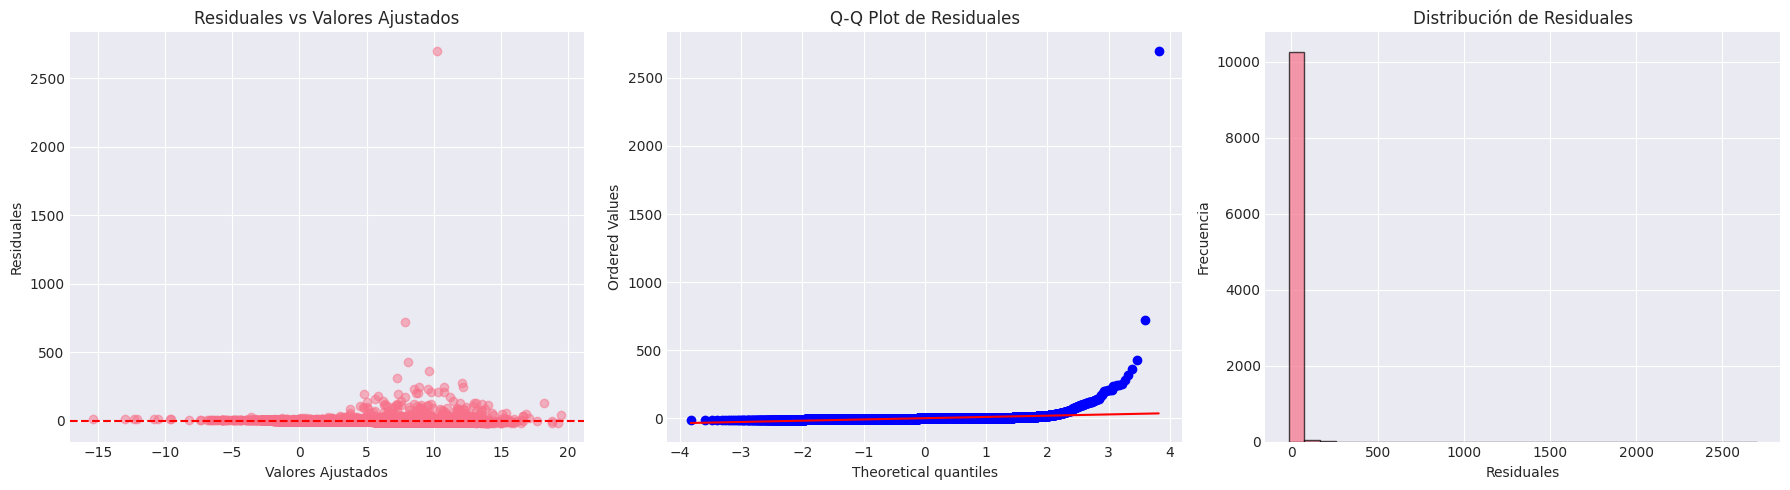

In [ ]:
if linear_model is not None:
    # Residual plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Residuals vs Fitted
    axes[0].scatter(linear_model.fittedvalues, linear_model.resid, alpha=0.5)
    axes[0].axhline(y=0, color='r', linestyle='--')
    axes[0].set_xlabel('Valores Ajustados')
    axes[0].set_ylabel('Residuales')
    axes[0].set_title('Residuales vs Valores Ajustados')
    
    # Q-Q Plot for residuals
    stats.probplot(linear_model.resid, dist="norm", plot=axes[1])
    axes[1].set_title('Q-Q Plot de Residuales')
    
    # Histogram of residuals
    axes[2].hist(linear_model.resid, bins=30, edgecolor='black', alpha=0.7)
    axes[2].set_xlabel('Residuales')
    axes[2].set_ylabel('Frecuencia')
    axes[2].set_title('Distribución de Residuales')
    
    plt.tight_layout()
    plt.show()

#### 4.2.3 Regresión de Poisson: Conteo de Instalaciones

<!-- **Pregunta de investigación**: ¿Qué factores predicen el número de instalaciones solares en un census tract?

**Variable dependiente**: `n_solar` (conteo de instalaciones, valores enteros no-negativos) -->

**Por qué Poisson?**:
- Datos de conteo (0, 1, 2, 3, ...)
- Varianza aumenta con la media (heterocedasticidad)
- No puede predecir valores negativos

**Métricas**:
- **Coeficientes exponenciados**: Multiplicador del conteo esperado
- **Pseudo-R²**: Ajuste del modelo
- **Deviance**: Bondad de ajuste (menor es mejor)

In [ ]:
# Prepare data for Poisson regression - use all tracts
poisson_data = analysis_clean[['n_solar'] + analysis_vars].dropna()

# Standardize predictors
for var in analysis_vars:
    poisson_data[f'{var}_std'] = (poisson_data[var] - poisson_data[var].mean()) / poisson_data[var].std()

formula_poisson = f"n_solar ~ {' + '.join(std_vars)}"

print("\n📊 Modelo de Regresión de Poisson")
print("=" * 60)
print(f"   Variable dependiente: n_solar (conteo de instalaciones)")
print(f"   Variables independientes: {analysis_vars}")
print(f"   Observaciones: {len(poisson_data):,}")

# Fit Poisson regression model
try:
    poisson_model = smf.poisson(formula=formula_poisson, data=poisson_data).fit(disp=0)
    print(poisson_model.summary())
    
    # Display exponentiated coefficients (multiplicative effects)
    print("\n📊 Coeficientes exponenciados (multiplicadores de conteo):")
    print("=" * 60)
    exp_coefs = np.exp(poisson_model.params)
    for var in std_vars:
        if var in exp_coefs.index:
            exp_coef = exp_coefs[var]
            pval = poisson_model.pvalues[var]
            sig = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else ''))
            orig_var = var.replace('_std', '')
            pct_change = (exp_coef - 1) * 100
            direction = "aumenta" if exp_coef > 1 else "disminuye"
            print(f"   {orig_var}: exp(β)={exp_coef:.3f} {sig}")
            print(f"      → 1 SD de aumento {direction} el conteo esperado en {abs(pct_change):.1f}%")
    
    print("\n📏 Ajuste del modelo:")
    print(f"   Pseudo-R² (McFadden): {poisson_model.prsquared:.4f}")
    print(f"   Log-Likelihood: {poisson_model.llf:.2f}")
    print(f"   Deviance: {poisson_model.deviance:.2f}")
    print(f"   Pearson χ²: {poisson_model.pearson_chi2:.2f}")
    print(f"   AIC: {poisson_model.aic:.2f}")
    print(f"   BIC: {poisson_model.bic:.2f}")
    
    # Check for overdispersion
    overdispersion_ratio = poisson_model.pearson_chi2 / poisson_model.df_resid
    print(f"\n🔍 Diagnóstico de sobredispersión:")
    print(f"   Ratio Pearson χ²/df: {overdispersion_ratio:.2f}")
    if overdispersion_ratio > 1.5:
        print(f"   ⚠️ Sobredispersión detectada (ratio > 1.5)")
        print(f"   → Considerar modelo Negative Binomial en lugar de Poisson")
    else:
        print(f"   ✓ No hay sobredispersión significativa")
    
except Exception as e:
    print(f"⚠️ Error al ajustar el modelo: {e}")
    poisson_model = None


📊 Modelo de Regresión de Poisson
   Variable dependiente: n_solar (conteo de instalaciones)
   Variables independientes: ['total_population', 'median_household_income', 'population_below_poverty', 'median_home_value', 'total_housing_units', 'pct_unemployment', 'pct_bachelors_or_higher', 'pct_hispanic', 'population_density', 'diversity_index']
   Observaciones: 81,081
                          Poisson Regression Results                          
Dep. Variable:                n_solar   No. Observations:                81081
Model:                        Poisson   Df Residuals:                    81070
Method:                           MLE   Df Model:                           10
Date:                Sun, 07 Dec 2025   Pseudo R-squ.:                  0.1278
Time:                        06:46:21   Log-Likelihood:            -2.2864e+05
converged:                       True   LL-Null:                   -2.6214e+05
Covariance Type:            nonrobust   LLR p-value:                     0.0

#### 4.2.4 Comparación de Modelos

Comparamos los tres modelos para entender cómo responden a diferentes preguntas de investigación:

In [ ]:
if all([logit_model is not None, linear_model is not None, poisson_model is not None]):
    print("\n📊 Resumen Comparativo de Modelos")
    print("=" * 80)
    
    comparison_df = pd.DataFrame({
        'Modelo': ['Logística', 'Lineal (OLS)', 'Poisson'],
        'Variable Dependiente': ['has_solar (binaria)', 'solar_adoption_rate (continua)', 'n_solar (conteo)'],
        'N Observaciones': [len(logit_data), len(linear_data), len(poisson_data)],
        'R² / Pseudo-R²': [f"{logit_model.prsquared:.4f}", f"{linear_model.rsquared:.4f}", f"{poisson_model.prsquared:.4f}"],
        'AIC': [f"{logit_model.aic:.2f}", f"{linear_model.aic:.2f}", f"{poisson_model.aic:.2f}"],
        'Pregunta': [
            '¿Tiene instalaciones FV?',
            '¿Cuánta adopción (rate)?',
            '¿Cuántas instalaciones (count)?'
        ]
    })
    
    display(comparison_df)
    
    print("\n💡 Interpretación:")
    print("   - Logística: Identifica factores asociados con presencia/ausencia de solar")
    print("   - Lineal: Entre tracts con solar, predice intensidad de adopción")
    print("   - Poisson: Modela conteos esperados de instalaciones por tract")
    print("\n   Los tres modelos se complementan para un análisis comprehensivo.")

---

## 🎯 5: Conclusiones y Próximos Pasos

### Hallazgos Principales:

1. **Distribución de datos**: La mayoría de las variables del Censo NO siguen una distribución normal, justificando el uso de pruebas no paramétricas (Mann-Whitney U).

2. **Poder estadístico**: Con nuestros tamaños de muestra, tenemos poder suficiente para detectar efectos pequeños a grandes.

3. **Clustering HDBSCAN**: Identificamos patrones naturales en los datos que revelan perfiles socioeconómicos distintos. El test Chi-cuadrado muestra si estos clusters están asociados significativamente con la presencia de instalaciones FV.

4. **Diferencias significativas**: Las pruebas de hipótesis identifican qué variables del Censo difieren significativamente entre tracts con y sin instalaciones FV.

5. **Modelos de regresión complementarios**:
   - **Logística**: Factores que predicen presencia/ausencia de solar
   - **Lineal**: Entre tracts con solar, qué predice mayor adopción
   - **Poisson**: Modelado de conteos esperados de instalaciones

6. **Métrica de adopción**: `solar_adoption_rate` (instalaciones por 1,000 unidades de vivienda) es una métrica más interpretable que `solar_density` para comparar adopción entre tracts urbanos y rurales.

### Análisis Completados:

- ✅ Integración de datos del Censo 2020 (estado, county, tract)
- ✅ Integración de Land Cover/Land Use (LULC) con optimización por tract
- ✅ Análisis de datos faltantes y caracterización MCAR/MAR/MNAR
- ✅ Imputación MICE para `capacity_mw` 
- ✅ Clustering basado en densidad (HDBSCAN)
- ✅ Pruebas de normalidad (Shapiro-Wilk, K-S)
- ✅ Análisis de poder estadístico
- ✅ Pruebas de hipótesis (t-test / Mann-Whitney U con tamaños de efecto)
- ✅ Regresión logística para presencia de solar
- ✅ Regresión lineal para tasa de adopción
- ✅ Regresión de Poisson para conteo de instalaciones

### Próximos Pasos para Part A (Due: Dec 8, 2025):

- [REU Hoy] **Refinamiento de hipótesis**: Consolidar hallazgos de clustering y regresiones para definir hipótesis principal y sub-hipótesis
- [Drafted] **Poster**: Abstract, pregunta de investigación, métodos, resultados, conclusiones, referencias
- [Drafted] **PDF de métodos**: 1-2 páginas expandiendo la sección de métodos del poster
- [Needs work and testing] **Documentación de reproducibilidad**: Actualizar README con instrucciones de ejecución

### 🔬 Trabajo Futuro (Part B):

La variable `capacity_mw` (capacidad de generación en megavatios) es un excelente candidato para **imputación o derivación** basada en:

1. **Área del panel (`area_m2`)**: Existe una relación física directa entre área y capacidad
   - Regla general: ~150-200 W/m² para paneles cristalinos típicos
   - Fórmula aproximada: `capacity_kw ≈ area_m2 * 0.15 a 0.20`

2. **Ángulo de inclinación del panel**: Si está disponible, mejora significativamente la precisión
   - Paneles con inclinación óptima (latitud ± 15°) maximizan generación

3. **Modelos físicos de energía existentes**:
   - **PVWatts** (NREL): Modelo estándar de la industria para estimación de generación
   - **SAM** (System Advisor Model): Modelo más detallado que incluye degradación y pérdidas
   - Parámetros: radiación solar local, temperatura, eficiencia del panel, orientación

Esta imputación permitiría análisis más completos sobre la capacidad de generación agregada por tract.

## 📚 Referencias y Documentación

### Censusdis y API del Censo
- [censusdis Introduction](https://censusdis.readthedocs.io/en/latest/intro.html)
- [Census API Datasets](https://api.census.gov/data/2020.html)
- [Exploring Variables](https://censusdis.readthedocs.io/en/latest/nb/Exploring%20Variables.html)
- [Data With Geometry](https://censusdis.readthedocs.io/en/latest/nb/Data%20With%20Geometry.html)
- [Column Labels (Human-friendly names)](https://github.com/censusdis/censusdis/blob/main/notebooks/Column%20Labels.ipynb)
- [Population Density](https://github.com/censusdis/censusdis/blob/main/notebooks/Population%20Density.ipynb)

### Análisis Estadístico
- [SciPy Stats Documentation](https://docs.scipy.org/doc/scipy/reference/stats.html)
- [Statsmodels Power Analysis](https://www.statsmodels.org/stable/stats.html#power-and-sample-size-calculations)
- [Mann-Whitney U Test](https://en.wikipedia.org/wiki/Mann%E2%80%93Whitney_U_test)

### Visualización
- [ipywidgets Widget List](https://ipywidgets.readthedocs.io/en/latest/examples/Widget%20List.html)
- [Plotly Express Documentation](https://plotly.com/python/plotly-express/)